# Validação metodológica — case Vértice / MIPO\n\nNotebook organizado para publicação. Os caminhos de dados são relativos a `../data/`. As bases brutas não acompanham o repositório público. Resultados representam evidência histórica ou estimativa; associação não implica causalidade e exposição não equivale a perda comprovada.

# AI Consulting Lab — Projeto Vértice
## Análise Exploratória de Dados v2

**Objetivo:** testar, com evidências reproduzíveis, quais problemas a solução deve resolver e quais módulos de IA/ML são defensáveis com os dados disponíveis.

Esta versão preserva a EDA original e adota quatro regras:

1. separar fato observado, cenário e causalidade;
2. reportar tamanho de efeito, não apenas significância estatística;
3. transformar limitações de dados em requisitos do produto;
4. permitir que um resultado negativo de ML produza uma decisão de `no-go`.

**Saída final:** registro de hipóteses e backlog do MVP orientado por evidências.

### Perguntas de decisão

- Existe deterioração estrutural da margem ou vazamentos concentrados?
- Quais canais, categorias e processos merecem intervenção nos próximos 90 dias?
- As bases permitem atribuir marketing a margem e LTV?
- Atendimento e devoluções permitem automação ou modelagem preditiva confiável?
- O histórico disponível sustenta previsão de demanda?
- Que controles de qualidade devem fazer parte do MVP?

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
REFERENCE_DATE = pd.Timestamp('2026-01-01')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 100)

COLORS = {
    'purple': '#7B2CBF', 'blue': '#2563EB', 'green': '#15803D',
    'orange': '#EA580C', 'red': '#DC2626', 'gray': '#64748B', 'dark': '#111827'
}

def safe_div(numerator, denominator):
    return np.where(np.asarray(denominator) != 0, np.asarray(numerator) / np.asarray(denominator), np.nan)

def conclusion(title, text):
    display(Markdown(f'**Conclusão — {title}:** {text}'))

print('Ambiente carregado com seed fixa:', RANDOM_STATE)

Ambiente carregado com seed fixa: 42


In [2]:
DATA_DIR = Path('data')

vendas_raw = pd.read_csv(DATA_DIR / 'vendas.csv', encoding='utf-8-sig')
marketing = pd.read_csv(DATA_DIR / 'marketing.csv', encoding='utf-8-sig')
clientes = pd.read_csv(DATA_DIR / 'clientes.csv', encoding='utf-8-sig')
atendimento_raw = pd.read_csv(DATA_DIR / 'atendimento.csv', encoding='utf-8-sig')
estoque = pd.read_csv(DATA_DIR / 'estoque.csv', encoding='utf-8-sig')

# Conversões determinísticas e auditáveis.
vendas_raw['data_pedido'] = pd.to_datetime(vendas_raw['data_pedido'], errors='coerce')
marketing['data_inicio'] = pd.to_datetime(marketing['data_inicio'], errors='coerce')
marketing['data_fim'] = pd.to_datetime(marketing['data_fim'], errors='coerce')
clientes['data_nascimento'] = pd.to_datetime(clientes['data_nascimento'], errors='coerce')
clientes['data_cadastro'] = pd.to_datetime(clientes['data_cadastro'], errors='coerce')
atendimento_raw['data_abertura'] = pd.to_datetime(atendimento_raw['data_abertura'], errors='coerce')
atendimento_raw['data_fechamento'] = pd.to_datetime(atendimento_raw['data_fechamento'], errors='coerce')
estoque['data_ultima_entrada'] = pd.to_datetime(estoque['data_ultima_entrada'], errors='coerce')

vendas_raw['devolvido_num'] = (
    vendas_raw['devolvido'].astype(str).str.strip().str.lower()
    .map({'true': 1, 'false': 0})
)

vendas_required_rows = [
    'order_id', 'customer_id', 'sku_id', 'data_pedido', 'canal', 'categoria',
    'quantidade', 'receita_bruta', 'desconto_reais', 'receita_liquida',
    'custo_produto', 'custo_frete', 'margem_contribuicao', 'devolvido_num'
]
atendimento_required_rows = [
    'ticket_id', 'customer_id', 'order_id', 'data_abertura', 'categoria_problema',
    'status_atendimento', 'texto_cliente', 'nota_csat',
    'tempo_primeira_resposta_minutos', 'custo_operacional_ticket'
]

invalid_vendas = vendas_raw[vendas_required_rows].isna().any(axis=1)
invalid_atendimento = atendimento_raw[atendimento_required_rows].isna().any(axis=1)
vendas = vendas_raw.loc[~invalid_vendas].copy()
atendimento = atendimento_raw.loc[~invalid_atendimento].copy()

vendas['ano_mes'] = vendas['data_pedido'].dt.to_period('M')
vendas['margem_pct_pedido'] = 100 * vendas['margem_contribuicao'] / vendas['receita_bruta']
vendas['desconto_pct_pedido'] = 100 * vendas['desconto_reais'] / vendas['receita_bruta']
vendas['frete_pct_pedido'] = 100 * vendas['custo_frete'] / vendas['receita_bruta']
vendas['margem_negativa'] = vendas['margem_contribuicao'] < 0

datasets = {
    'Vendas': vendas, 'Marketing': marketing, 'Clientes': clientes,
    'Atendimento': atendimento, 'Estoque': estoque
}

carga = pd.DataFrame([
    {'dataset': nome, 'linhas_utilizáveis': len(df), 'colunas': df.shape[1]}
    for nome, df in datasets.items()
])
display(carga)
print(f'Registros excluídos explicitamente: vendas={invalid_vendas.sum()}, atendimento={invalid_atendimento.sum()}')

,dataset,linhas_utilizáveis,colunas
0,Vendas,27758,26
1,Marketing,3500,15
2,Clientes,15000,14
3,Atendimento,35840,12
4,Estoque,5000,16


Registros excluídos explicitamente: vendas=1, atendimento=1


## 1. Contrato e qualidade dos dados

Esta seção decide se uma análise pode ser executada, se deve receber menor confiança ou se precisa ser bloqueada.

In [3]:
REQUIRED_COLUMNS = {
    'Vendas': {'order_id', 'customer_id', 'sku_id', 'data_pedido', 'canal', 'categoria',
               'receita_bruta', 'desconto_reais', 'receita_liquida', 'custo_produto',
               'custo_frete', 'margem_contribuicao', 'devolvido'},
    'Marketing': {'campanha_id', 'canal', 'data_inicio', 'data_fim', 'investimento_reais',
                  'impressoes', 'cliques', 'conversoes', 'receita_gerada', 'roas', 'cac'},
    'Clientes': {'customer_id', 'data_cadastro', 'nivel_fidelidade', 'total_pedidos_historico',
                 'ltv_acumulado', 'segmento_rfm'},
    'Atendimento': {'ticket_id', 'customer_id', 'order_id', 'data_abertura',
                    'categoria_problema', 'texto_cliente', 'nota_csat',
                    'tempo_primeira_resposta_minutos', 'custo_operacional_ticket'},
    'Estoque': {'sku_id', 'categoria', 'estoque_fisico', 'estoque_reservado',
                'estoque_disponivel', 'ponto_pedido', 'status_disponibilidade',
                'custo_unitario', 'data_ultima_entrada'}
}
PRIMARY_KEYS = {
    'Vendas': 'order_id', 'Marketing': 'campanha_id', 'Clientes': 'customer_id',
    'Atendimento': 'ticket_id', 'Estoque': 'sku_id'
}

schema_checks = []
for nome, df in datasets.items():
    missing = sorted(REQUIRED_COLUMNS[nome] - set(df.columns))
    key = PRIMARY_KEYS[nome]
    schema_checks.append({
        'dataset': nome,
        'colunas_ausentes': ', '.join(missing) if missing else '—',
        'duplicidades_chave': int(df[key].duplicated().sum()),
        'linhas_com_algum_nulo': int(df.isna().any(axis=1).sum()),
        'status_schema': 'CRÍTICO' if missing else 'OK'
    })
schema_report = pd.DataFrame(schema_checks)
display(schema_report)

assert all(row == '—' for row in schema_report['colunas_ausentes'])
assert schema_report['duplicidades_chave'].sum() == 0
conclusion('contrato estrutural', 'As cinco bases possuem as colunas e chaves esperadas. Uma linha incompleta de vendas e uma de atendimento foram excluídas e permanecem registradas como avisos.')

,dataset,colunas_ausentes,duplicidades_chave,linhas_com_algum_nulo,status_schema
0,Vendas,—,0,0,OK
1,Marketing,—,0,0,OK
2,Clientes,—,0,0,OK
3,Atendimento,—,0,0,OK
4,Estoque,—,0,0,OK


**Conclusão — contrato estrutural:** As cinco bases possuem as colunas e chaves esperadas. Uma linha incompleta de vendas e uma de atendimento foram excluídas e permanecem registradas como avisos.

In [4]:
# Reconciliações que devem ser verdadeiras antes de qualquer hipótese.
gross_net_error = (vendas['receita_bruta'] - vendas['desconto_reais'] - vendas['receita_liquida']).abs()
margin_error = (
    vendas['receita_liquida'] - vendas['custo_produto'] - vendas['custo_frete']
    - vendas['margem_contribuicao']
).abs()
stock_error = (
    estoque['estoque_fisico'] - estoque['estoque_reservado'] - estoque['estoque_disponivel']
).abs()

consistency = pd.DataFrame([
    {'regra': 'receita_bruta - desconto = receita_liquida', 'máximo_erro': gross_net_error.max(), 'linhas_fora_tolerância': int((gross_net_error > 0.02).sum())},
    {'regra': 'receita_liquida - produto - frete = margem', 'máximo_erro': margin_error.max(), 'linhas_fora_tolerância': int((margin_error > 0.02).sum())},
    {'regra': 'estoque_físico = reservado + disponível', 'máximo_erro': stock_error.max(), 'linhas_fora_tolerância': int((stock_error > 0).sum())}
])
display(consistency.round(6))

assert gross_net_error.max() < 0.02
assert margin_error.max() < 0.02
assert stock_error.max() == 0
conclusion('reconciliação', 'As fórmulas registradas são internamente consistentes. Isso não significa que a margem já desconte reembolsos, recuperação de produto ou logística reversa.')

,regra,máximo_erro,linhas_fora_tolerância
0,receita_bruta - desconto = receita_liquida,0.0,0
1,receita_liquida - produto - frete = margem,0.0,0
2,estoque_físico = reservado + disponível,0.0,0


**Conclusão — reconciliação:** As fórmulas registradas são internamente consistentes. Isso não significa que a margem já desconte reembolsos, recuperação de produto ou logística reversa.

In [5]:
date_ranges = pd.DataFrame([
    {'dataset': 'Vendas', 'campo': 'data_pedido', 'início': vendas.data_pedido.min(), 'fim': vendas.data_pedido.max()},
    {'dataset': 'Marketing', 'campo': 'data_inicio', 'início': marketing.data_inicio.min(), 'fim': marketing.data_fim.max()},
    {'dataset': 'Clientes', 'campo': 'data_cadastro', 'início': clientes.data_cadastro.min(), 'fim': clientes.data_cadastro.max()},
    {'dataset': 'Atendimento', 'campo': 'data_abertura', 'início': atendimento.data_abertura.min(), 'fim': atendimento.data_abertura.max()},
    {'dataset': 'Estoque', 'campo': 'data_ultima_entrada', 'início': estoque.data_ultima_entrada.min(), 'fim': estoque.data_ultima_entrada.max()}
])

coverage = pd.DataFrame([
    {'relação': 'vendas.customer_id → clientes', 'cobertura_linhas_pct': 100 * vendas.customer_id.isin(clientes.customer_id).mean(), 'chaves_origem': vendas.customer_id.nunique(), 'chaves_com_match': vendas.loc[vendas.customer_id.isin(clientes.customer_id), 'customer_id'].nunique()},
    {'relação': 'atendimento.customer_id → clientes', 'cobertura_linhas_pct': 100 * atendimento.customer_id.isin(clientes.customer_id).mean(), 'chaves_origem': atendimento.customer_id.nunique(), 'chaves_com_match': atendimento.loc[atendimento.customer_id.isin(clientes.customer_id), 'customer_id'].nunique()},
    {'relação': 'atendimento.order_id → vendas', 'cobertura_linhas_pct': 100 * atendimento.order_id.isin(vendas.order_id).mean(), 'chaves_origem': atendimento.order_id.nunique(), 'chaves_com_match': atendimento.loc[atendimento.order_id.isin(vendas.order_id), 'order_id'].nunique()},
    {'relação': 'vendas.sku_id → estoque', 'cobertura_linhas_pct': 100 * vendas.sku_id.isin(estoque.sku_id).mean(), 'chaves_origem': vendas.sku_id.nunique(), 'chaves_com_match': vendas.loc[vendas.sku_id.isin(estoque.sku_id), 'sku_id'].nunique()}
])
display(date_ranges)
display(coverage.round(2))

customer_orders = vendas.groupby('customer_id')['order_id'].nunique().sort_values(ascending=False)
concentration = pd.DataFrame([
    {'grupo': 'Top 1 cliente', 'participação_pedidos_pct': 100 * customer_orders.head(1).sum() / customer_orders.sum()},
    {'grupo': 'Top 5 clientes', 'participação_pedidos_pct': 100 * customer_orders.head(5).sum() / customer_orders.sum()},
    {'grupo': 'Top 10 clientes', 'participação_pedidos_pct': 100 * customer_orders.head(10).sum() / customer_orders.sum()}
])
display(concentration.round(2))
conclusion('compatibilidade', 'As chaves existem, mas as populações e os períodos não são equivalentes: somente 2,3% da base de clientes aparece nas vendas e apenas 34,6% dos tickets encontra um pedido. A concentração extrema exige testes de sensibilidade.')

,dataset,campo,início,fim
0,Vendas,data_pedido,2023-01-01 00:05:25,2024-01-26 10:53:49
1,Marketing,data_inicio,2023-01-01 00:00:00,2025-12-31 00:00:00
2,Clientes,data_cadastro,2020-01-01 00:00:00,2025-12-28 00:00:00
3,Atendimento,data_abertura,2023-01-01 07:54:47,2025-12-31 21:11:32
4,Estoque,data_ultima_entrada,2023-01-01 00:00:00,2025-12-28 00:00:00


,relação,cobertura_linhas_pct,chaves_origem,chaves_com_match
0,vendas.customer_id → clientes,100.00,346,346
1,atendimento.customer_id → clientes,100.00,445,445
2,atendimento.order_id → vendas,34.61,28589,9865
3,vendas.sku_id → estoque,100.00,4918,4918


,grupo,participação_pedidos_pct
0,Top 1 cliente,40.64
1,Top 5 clientes,74.05
2,Top 10 clientes,83.15


**Conclusão — compatibilidade:** As chaves existem, mas as populações e os períodos não são equivalentes: somente 2,3% da base de clientes aparece nas vendas e apenas 34,6% dos tickets encontra um pedido. A concentração extrema exige testes de sensibilidade.

In [6]:
issues = pd.DataFrame([
    {'severidade': 'AVISO', 'tema': 'Linhas incompletas', 'evidência': f'{invalid_vendas.sum()} venda e {invalid_atendimento.sum()} ticket excluídos', 'impacto': 'Baixo; exclusão explícita'},
    {'severidade': 'LIMITAÇÃO', 'tema': 'Cobertura de clientes', 'evidência': f'{vendas.customer_id.nunique()} de {len(clientes):,} clientes ligados às vendas', 'impacto': 'Bloqueia inferência populacional de LTV/churn'},
    {'severidade': 'LIMITAÇÃO', 'tema': 'Cobertura de pedidos', 'evidência': f'{100 * atendimento.order_id.isin(vendas.order_id).mean():.1f}% dos tickets ligados às vendas', 'impacto': 'Reduz confiança dos cruzamentos pós-venda'},
    {'severidade': 'CRÍTICO', 'tema': 'Atribuição de marketing', 'evidência': 'Não existe campanha_id em vendas nem canal_aquisicao em clientes', 'impacto': 'Bloqueia otimizador de orçamento baseado em margem/LTV'},
    {'severidade': 'CRÍTICO', 'tema': 'Contabilidade de devoluções', 'evidência': 'Margem registrada ainda contabiliza receita líquida dos pedidos devolvidos', 'impacto': 'Bloqueia impacto realizado sem reembolso, recuperação e logística reversa'},
    {'severidade': 'LIMITAÇÃO', 'tema': 'Concentração', 'evidência': f'Top 10 = {100 * customer_orders.head(10).sum() / customer_orders.sum():.1f}% dos pedidos', 'impacto': 'Exige análise com e sem outliers'}
])
display(issues)

,severidade,tema,evidência,impacto
0,AVISO,Linhas incompletas,1 venda e 1 ticket excluídos,Baixo; exclusão explícita
1,LIMITAÇÃO,Cobertura de clientes,"346 de 15,000 clientes ligados às vendas",Bloqueia inferência populacional de LTV/churn
2,LIMITAÇÃO,Cobertura de pedidos,34.6% dos tickets ligados às vendas,Reduz confiança dos cruzamentos pós-venda
3,CRÍTICO,Atribuição de marketing,Não existe campanha_id em vendas nem canal_aquisicao em clientes,Bloqueia otimizador de orçamento baseado em margem/LTV
4,CRÍTICO,Contabilidade de devoluções,Margem registrada ainda contabiliza receita líquida dos pedidos devolvidos,"Bloqueia impacto realizado sem reembolso, recuperação e logística reversa"
5,LIMITAÇÃO,Concentração,Top 10 = 83.2% dos pedidos,Exige análise com e sem outliers


## 2. Vendas e margem

O objetivo é localizar vazamentos materiais e distinguir oscilações pontuais de deterioração estrutural.

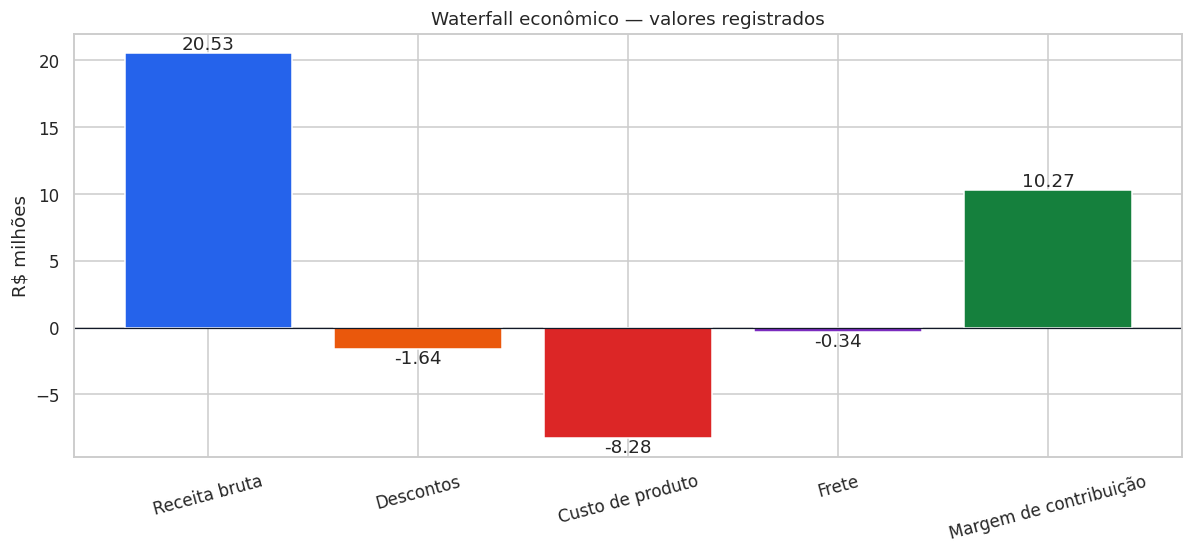

Receita bruta: R$ 20,526,133.84
Margem registrada: R$ 10,270,436.65 (50.04%)


**Conclusão — waterfall:** A margem registrada é internamente reconciliada, mas ainda não representa margem pós-devolução. O MVP deve mostrar explicitamente a base contábil de cada impacto.

In [7]:
totals = {
    'Receita bruta': vendas.receita_bruta.sum(),
    'Descontos': -vendas.desconto_reais.sum(),
    'Custo de produto': -vendas.custo_produto.sum(),
    'Frete': -vendas.custo_frete.sum(),
    'Margem de contribuição': vendas.margem_contribuicao.sum()
}
colors = [COLORS['blue'], COLORS['orange'], COLORS['red'], COLORS['purple'], COLORS['green']]
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(totals.keys(), np.array(list(totals.values())) / 1e6, color=colors)
ax.axhline(0, color=COLORS['dark'], linewidth=0.8)
ax.set_ylabel('R$ milhões')
ax.set_title('Waterfall econômico — valores registrados')
ax.bar_label(bars, fmt='%.2f')
plt.xticks(rotation=15)
plt.show()

margem_geral = 100 * vendas.margem_contribuicao.sum() / vendas.receita_bruta.sum()
print(f'Receita bruta: R$ {vendas.receita_bruta.sum():,.2f}')
print(f'Margem registrada: R$ {vendas.margem_contribuicao.sum():,.2f} ({margem_geral:.2f}%)')
conclusion('waterfall', 'A margem registrada é internamente reconciliada, mas ainda não representa margem pós-devolução. O MVP deve mostrar explicitamente a base contábil de cada impacto.')

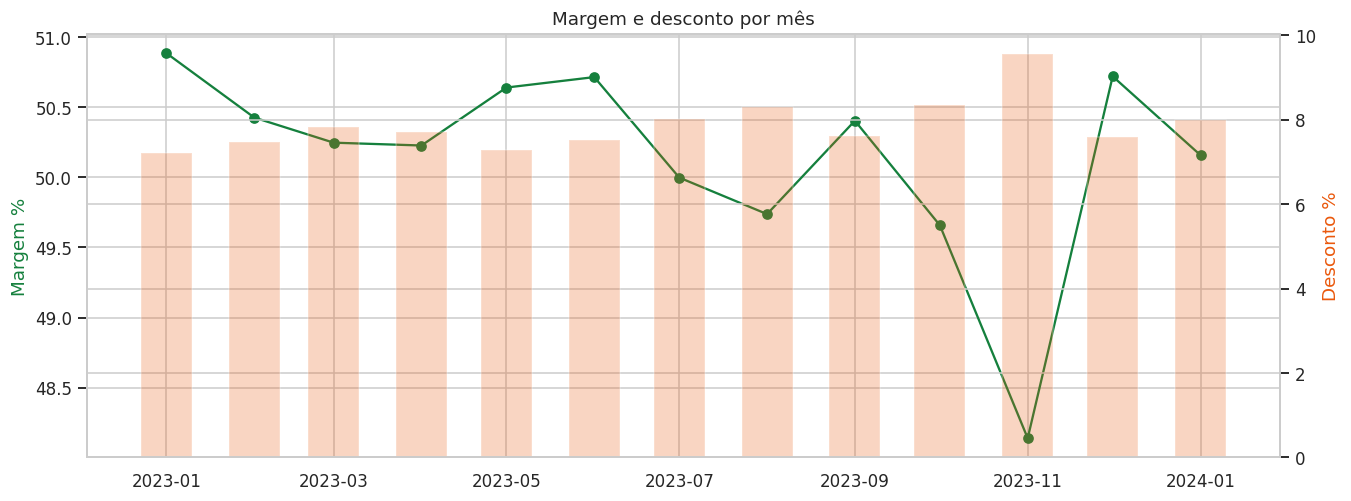

Inclinação: -0.080 p.p./mês | p=0.136 | IC95% [-0.189, 0.029]
Correlação mensal desconto×margem: -0.982


**Conclusão — tendência temporal:** A inclinação é negativa, mas não significativa a 5% e o intervalo inclui zero. A hipótese de deterioração estrutural permanece inconclusiva; novembro é um vazamento promocional pontual.

In [8]:
monthly = vendas.set_index('data_pedido').resample('MS').agg(
    receita=('receita_bruta', 'sum'), margem=('margem_contribuicao', 'sum'),
    desconto=('desconto_reais', 'sum'), pedidos=('order_id', 'nunique')
)
monthly['margem_pct'] = 100 * monthly.margem / monthly.receita
monthly['desconto_pct'] = 100 * monthly.desconto / monthly.receita

trend = stats.linregress(np.arange(len(monthly)), monthly.margem_pct)
slope_ci = (
    trend.slope - stats.t.ppf(0.975, len(monthly) - 2) * trend.stderr,
    trend.slope + stats.t.ppf(0.975, len(monthly) - 2) * trend.stderr
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly.index, monthly.margem_pct, marker='o', color=COLORS['green'], label='Margem %')
ax1.set_ylabel('Margem %', color=COLORS['green'])
ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly.desconto_pct, width=18, alpha=0.25, color=COLORS['orange'], label='Desconto %')
ax2.set_ylabel('Desconto %', color=COLORS['orange'])
ax1.set_title('Margem e desconto por mês')
plt.show()

print(f'Inclinação: {trend.slope:.3f} p.p./mês | p={trend.pvalue:.3f} | IC95% [{slope_ci[0]:.3f}, {slope_ci[1]:.3f}]')
print(f'Correlação mensal desconto×margem: {monthly[["desconto_pct", "margem_pct"]].corr().iloc[0, 1]:.3f}')
conclusion('tendência temporal', 'A inclinação é negativa, mas não significativa a 5% e o intervalo inclui zero. A hipótese de deterioração estrutural permanece inconclusiva; novembro é um vazamento promocional pontual.')

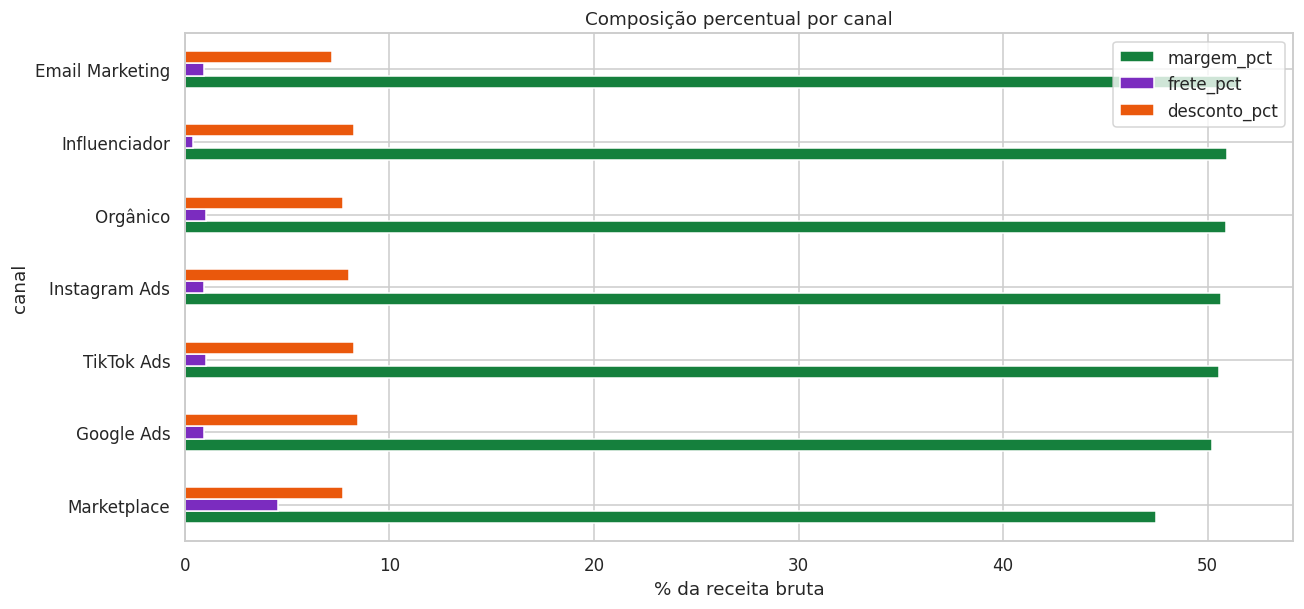

,receita,pedidos,margem_pct,frete_pct,desconto_pct,produto_pct
canal,,,,,,
Marketplace,4320195.69,6040,47.45,4.55,7.72,40.27
Google Ads,3979241.06,5504,50.20,0.93,8.46,40.41
TikTok Ads,2065684.06,2928,50.56,1.03,8.26,40.15
Instagram Ads,3555245.17,4965,50.64,0.96,8.00,40.41
Orgânico,2316434.49,3246,50.90,1.02,7.71,40.36
Influenciador,2250914.31,2263,50.96,0.39,8.27,40.38
Email Marketing,2038419.06,2812,51.59,0.93,7.20,40.27


Kruskal p=3.411e-117 | eta²=0.0107
Cenário: elevar Marketplace à margem geral = R$ 111,614.74


**Conclusão — Marketplace:** A diferença é estatisticamente clara, mas o tamanho de efeito global é pequeno. O Marketplace é acionável porque seu frete consome 4,55% da receita; a oportunidade calculada é cenário, não impacto garantido.

In [9]:
channel = vendas.groupby('canal').agg(
    receita=('receita_bruta', 'sum'), margem=('margem_contribuicao', 'sum'),
    desconto=('desconto_reais', 'sum'), produto=('custo_produto', 'sum'),
    frete=('custo_frete', 'sum'), pedidos=('order_id', 'nunique')
)
for col in ['margem', 'desconto', 'produto', 'frete']:
    channel[f'{col}_pct'] = 100 * channel[col] / channel.receita

samples = [group.margem_pct_pedido.values for _, group in vendas.groupby('canal')]
kruskal = stats.kruskal(*samples)
grand_mean = vendas.margem_pct_pedido.mean()
ss_between = sum(len(group) * (group.margem_pct_pedido.mean() - grand_mean) ** 2 for _, group in vendas.groupby('canal'))
eta_squared = ss_between / ((vendas.margem_pct_pedido - grand_mean) ** 2).sum()

plot_data = channel[['margem_pct', 'frete_pct', 'desconto_pct']].sort_values('margem_pct')
plot_data.plot(kind='barh', figsize=(13, 6), color=[COLORS['green'], COLORS['purple'], COLORS['orange']])
plt.title('Composição percentual por canal')
plt.xlabel('% da receita bruta')
plt.show()
display(channel[['receita', 'pedidos', 'margem_pct', 'frete_pct', 'desconto_pct', 'produto_pct']].sort_values('margem_pct').round(2))

marketplace = channel.loc['Marketplace']
opportunity_marketplace = marketplace.receita * (margem_geral - marketplace.margem_pct) / 100
print(f'Kruskal p={kruskal.pvalue:.3e} | eta²={eta_squared:.4f}')
print(f'Cenário: elevar Marketplace à margem geral = R$ {opportunity_marketplace:,.2f}')
conclusion('Marketplace', 'A diferença é estatisticamente clara, mas o tamanho de efeito global é pequeno. O Marketplace é acionável porque seu frete consome 4,55% da receita; a oportunidade calculada é cenário, não impacto garantido.')

In [10]:
negative = vendas[vendas.margem_negativa]
negative_drivers = vendas.groupby('margem_negativa').agg(
    pedidos=('order_id', 'count'),
    receita_média=('receita_bruta', 'mean'),
    desconto_pct=('desconto_pct_pedido', 'mean'),
    frete_pct=('frete_pct_pedido', 'mean'),
    margem_total=('margem_contribuicao', 'sum')
)

def metrics_without_top(n):
    top = customer_orders.head(n).index if n else []
    sample = vendas[~vendas.customer_id.isin(top)]
    return {
        'remoção': f'Top {n}' if n else 'Nenhuma',
        'linhas': len(sample),
        'receita_mi': sample.receita_bruta.sum() / 1e6,
        'margem_pct': 100 * sample.margem_contribuicao.sum() / sample.receita_bruta.sum(),
        'devolução_pct': 100 * sample.devolvido_num.mean(),
        'pedidos_negativos_pct': 100 * sample.margem_negativa.mean()
    }

sensitivity_sales = pd.DataFrame([metrics_without_top(n) for n in [0, 1, 5, 10]])
display(negative_drivers.round(2))
display(sensitivity_sales.round(2))
print(f'Pedidos negativos: {len(negative):,} ({100 * len(negative) / len(vendas):.2f}%) | perda R$ {negative.margem_contribuicao.sum():,.2f}')
conclusion('perdas e concentração', 'Pedidos negativos têm frete e desconto percentualmente altos, mas a perda de R$ 6,6 mil é imaterial diante das devoluções. As taxas permanecem estáveis sem os maiores clientes, enquanto o volume total é extremamente sensível.')

,pedidos,receita_média,desconto_pct,frete_pct,margem_total
margem_negativa,,,,,
False,27267,750.87,7.78,4.41,10277072.76
True,491,105.98,21.84,54.10,-6636.11


,remoção,linhas,receita_mi,margem_pct,devolução_pct,pedidos_negativos_pct
0,Nenhuma,27758,20.53,50.04,14.87,1.77
1,Top 1,16476,12.17,50.00,14.80,1.80
2,Top 5,7202,5.30,49.91,14.38,1.78
3,Top 10,4676,3.48,49.88,14.76,1.67


Pedidos negativos: 491 (1.77%) | perda R$ -6,636.11


**Conclusão — perdas e concentração:** Pedidos negativos têm frete e desconto percentualmente altos, mas a perda de R$ 6,6 mil é imaterial diante das devoluções. As taxas permanecem estáveis sem os maiores clientes, enquanto o volume total é extremamente sensível.

In [11]:
returned = vendas[vendas.devolvido_num == 1]
returned_net = returned.receita_liquida.sum()
returned_cost = returned.custo_produto.sum()
returned_outbound_freight = returned.custo_frete.sum()
recorded_margin = vendas.margem_contribuicao.sum()

return_scenarios = pd.DataFrame([
    {
        'recuperação_produto_pct': recovery * 100,
        'margem_ajustada_antes_logística_reversa': recorded_margin - returned_net + recovery * returned_cost,
        'margem_ajustada_pct_receita_bruta': 100 * (recorded_margin - returned_net + recovery * returned_cost) / vendas.receita_bruta.sum()
    }
    for recovery in [0, 0.5, 1]
])
display(return_scenarios.round(2))
print(f'Devoluções: {len(returned):,} ({100 * len(returned) / len(vendas):.2f}%)')
print(f'Receita bruta associada: R$ {returned.receita_bruta.sum():,.2f}')
print(f'Receita líquida a estornar no cenário: R$ {returned_net:,.2f}')
print(f'Frete de ida já incorrido: R$ {returned_outbound_freight:,.2f}')
conclusion('devoluções', 'O valor realizado não é verificável sem reembolso, recuperação do item, logística reversa e custo de processamento. O produto deve oferecer cenários editáveis e nunca chamar receita bruta associada de margem recuperada.')

,recuperação_produto_pct,margem_ajustada_antes_logística_reversa,margem_ajustada_pct_receita_bruta
0,0.0,7453735.10,36.31
1,50.0,8074988.46,39.34
2,100.0,8696241.83,42.37


Devoluções: 4,127 (14.87%)
Receita bruta associada: R$ 3,063,301.17
Receita líquida a estornar no cenário: R$ 2,816,701.55
Frete de ida já incorrido: R$ 51,006.15


**Conclusão — devoluções:** O valor realizado não é verificável sem reembolso, recuperação do item, logística reversa e custo de processamento. O produto deve oferecer cenários editáveis e nunca chamar receita bruta associada de margem recuperada.

## 3. Marketing

A análise separa eficiência interna da base de marketing de atribuição financeira entre bases.

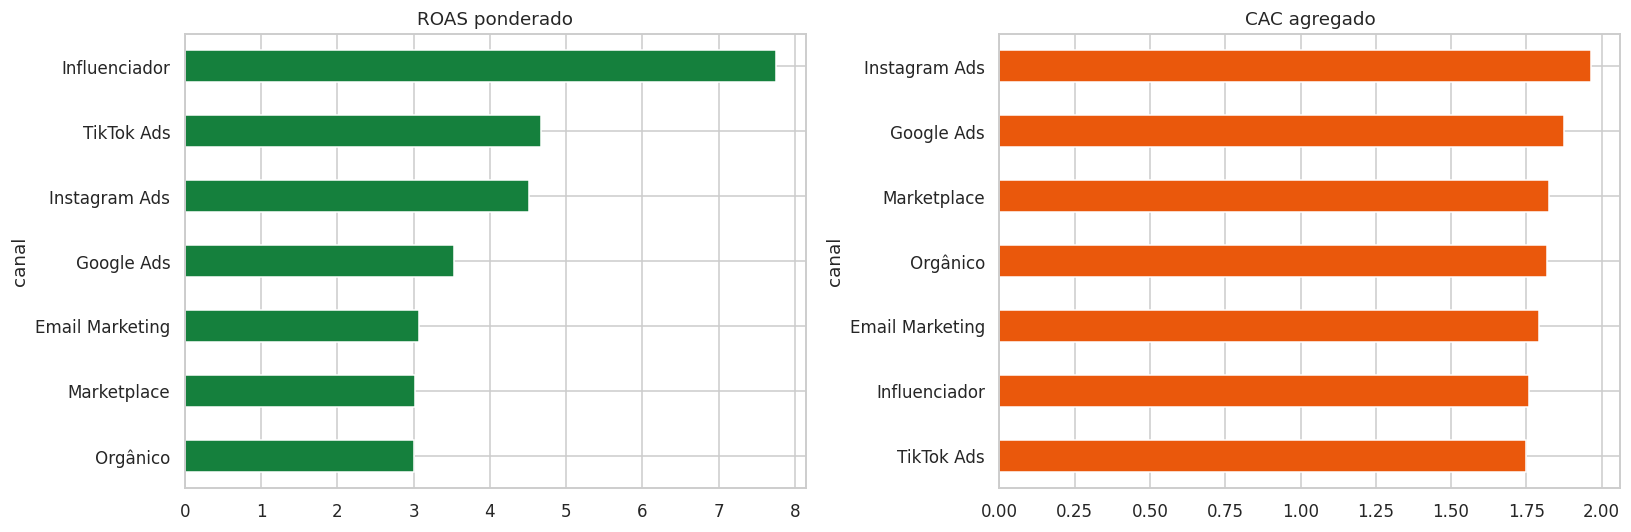

,investimento,receita,impressoes,cliques,conversoes,campanhas,roas_médio_campanhas,roas_dp,roas_ponderado,cac_agregado,ctr_pct,cvr_pct
canal,,,,,,,,,,,,
Influenciador,28061599.02,2.175780e+08,6734376424,241081421,15940484,465,7.69,4.15,7.75,1.76,3.58,6.61
TikTok Ads,29770101.07,1.390634e+08,7258701523,258038032,17009948,488,4.67,1.97,4.67,1.75,3.55,6.59
Instagram Ads,30165772.33,1.359386e+08,7036628198,233280842,15360484,518,4.43,1.40,4.51,1.96,3.32,6.58
Google Ads,30224839.25,1.065574e+08,7276888260,250841055,16118323,509,3.51,0.29,3.53,1.88,3.45,6.43
Email Marketing,29700531.98,9.104621e+07,7190708958,248127946,16563197,485,3.00,1.14,3.07,1.79,3.45,6.68
Marketplace,32682629.69,9.879591e+07,8028787619,271482915,17894187,540,3.00,1.14,3.02,1.83,3.38,6.59
Orgânico,29808867.75,8.964926e+07,7090741183,234763601,16401820,495,2.99,1.15,3.01,1.82,3.31,6.99


**Conclusão — eficiência interna de marketing:** Influenciador lidera o ROAS ponderado, mas a dispersão entre campanhas exige monitoramento no nível da campanha. CAC médio por linha não substitui CAC agregado.

In [12]:
marketing_channel = marketing.groupby('canal').agg(
    investimento=('investimento_reais', 'sum'), receita=('receita_gerada', 'sum'),
    impressoes=('impressoes', 'sum'), cliques=('cliques', 'sum'),
    conversoes=('conversoes', 'sum'), campanhas=('campanha_id', 'nunique'),
    roas_médio_campanhas=('roas', 'mean'), roas_dp=('roas', 'std')
)
marketing_channel['roas_ponderado'] = marketing_channel.receita / marketing_channel.investimento
marketing_channel['cac_agregado'] = marketing_channel.investimento / marketing_channel.conversoes
marketing_channel['ctr_pct'] = 100 * marketing_channel.cliques / marketing_channel.impressoes
marketing_channel['cvr_pct'] = 100 * marketing_channel.conversoes / marketing_channel.cliques

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
marketing_channel.roas_ponderado.sort_values().plot(kind='barh', ax=axes[0], color=COLORS['green'], title='ROAS ponderado')
marketing_channel.cac_agregado.sort_values().plot(kind='barh', ax=axes[1], color=COLORS['orange'], title='CAC agregado')
plt.tight_layout()
plt.show()
display(marketing_channel.round(2).sort_values('roas_ponderado', ascending=False))
conclusion('eficiência interna de marketing', 'Influenciador lidera o ROAS ponderado, mas a dispersão entre campanhas exige monitoramento no nível da campanha. CAC médio por linha não substitui CAC agregado.')

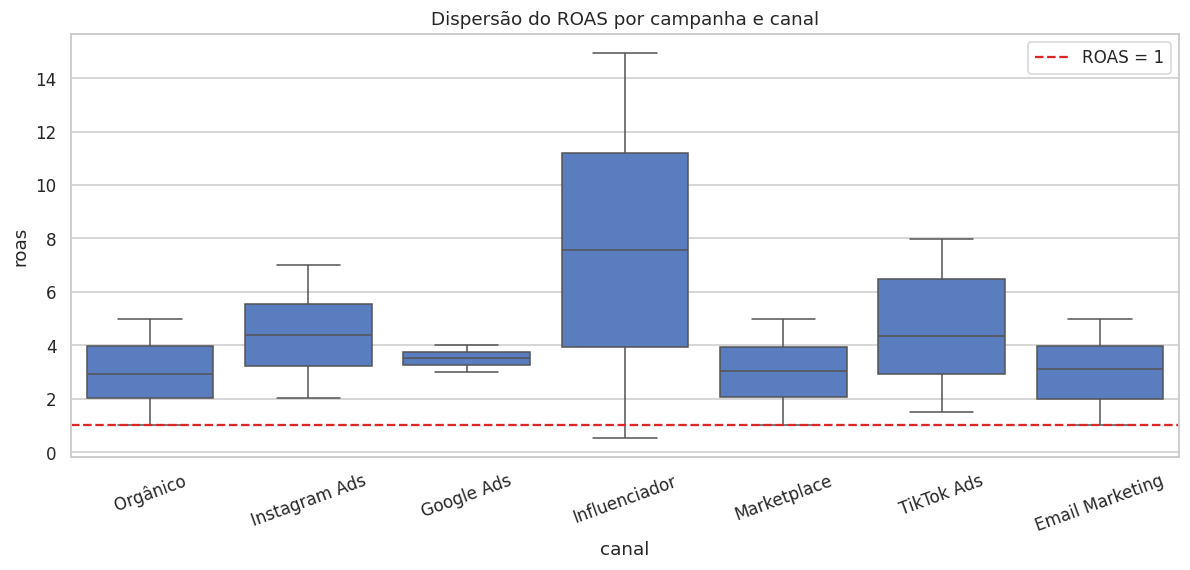

,métrica,valor,complemento
0,Campanhas com ROAS < 1,12.00,0.34% das campanhas
1,Investimento nessas campanhas,862436.67,0.41% do investimento
2,Campanhas no período de vendas,1224.00,"R$ 75,499,423.65 investidos"
3,Receita bruta registrada em vendas,20526133.84,população/atribuição incompatível


**Conclusão — atribuição:** Um monitor de campanhas é viável dentro da base de marketing. Um otimizador de orçamento baseado em margem ou LTV é bloqueado porque não há campanha→pedido→cliente e os universos financeiros não reconciliam.

In [13]:
low_roas = marketing[marketing.roas < 1]
overlap = marketing[
    marketing.data_inicio.between(vendas.data_pedido.min().normalize(), vendas.data_pedido.max().normalize())
]

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=marketing, x='canal', y='roas', showfliers=False, ax=ax)
ax.axhline(1, color=COLORS['red'], linestyle='--', label='ROAS = 1')
ax.set_title('Dispersão do ROAS por campanha e canal')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.show()

marketing_findings = pd.DataFrame([
    {'métrica': 'Campanhas com ROAS < 1', 'valor': len(low_roas), 'complemento': f'{100 * len(low_roas) / len(marketing):.2f}% das campanhas'},
    {'métrica': 'Investimento nessas campanhas', 'valor': low_roas.investimento_reais.sum(), 'complemento': f'{100 * low_roas.investimento_reais.sum() / marketing.investimento_reais.sum():.2f}% do investimento'},
    {'métrica': 'Campanhas no período de vendas', 'valor': len(overlap), 'complemento': f'R$ {overlap.investimento_reais.sum():,.2f} investidos'},
    {'métrica': 'Receita bruta registrada em vendas', 'valor': vendas.receita_bruta.sum(), 'complemento': 'população/atribuição incompatível'}
])
display(marketing_findings)
conclusion('atribuição', 'Um monitor de campanhas é viável dentro da base de marketing. Um otimizador de orçamento baseado em margem ou LTV é bloqueado porque não há campanha→pedido→cliente e os universos financeiros não reconciliam.')

## 4. Clientes

A segmentação cadastral será confrontada com a pequena e concentrada população ligada às vendas.

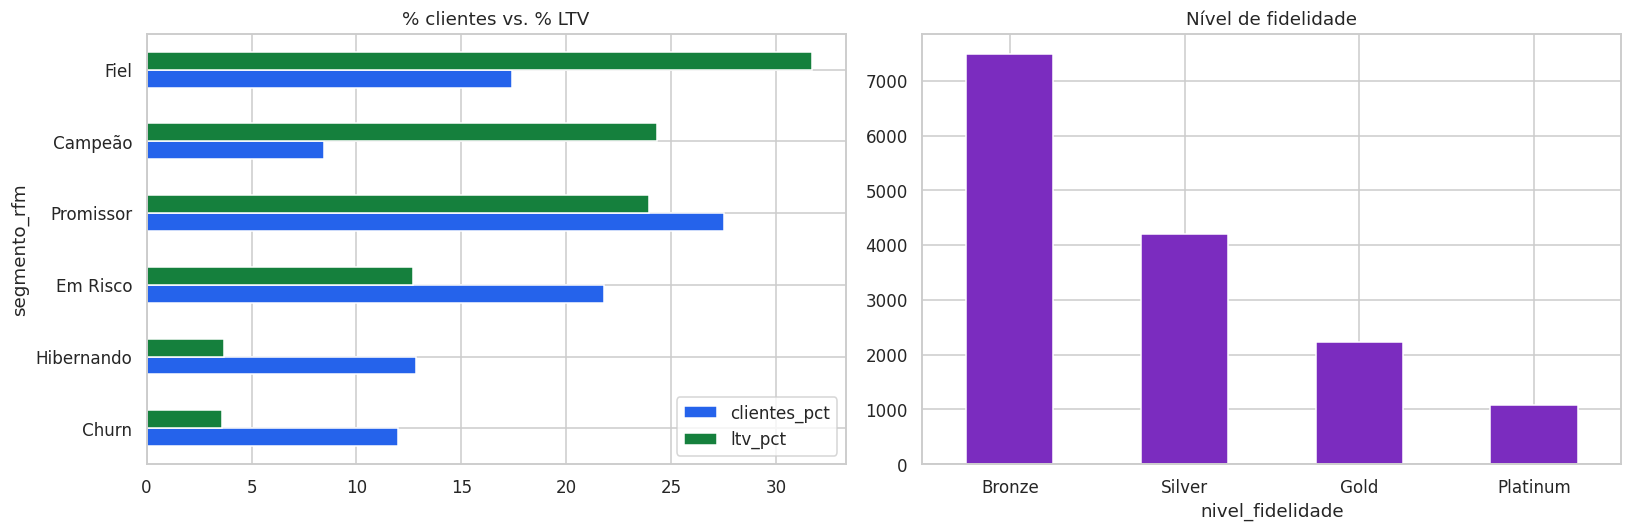

,clientes,ltv_médio,ltv_total,pedidos_históricos_médios,clientes_pct,ltv_pct
segmento_rfm,,,,,,
Campeão,1268,26670.76,33818518.33,54.01,8.45,24.31
Fiel,2612,16896.75,44134322.90,34.25,17.41,31.73
Promissor,4127,8077.97,33337782.88,15.98,27.51,23.97
Em Risco,3269,5403.48,17663986.57,10.70,21.79,12.70
Churn,1796,2782.08,4996623.83,5.42,11.97,3.59
Hibernando,1928,2666.67,5141334.33,5.33,12.85,3.70


**Conclusão — segmentação cadastral:** Campeões e Fiéis concentram valor cadastral, mas essa leitura descreve o cadastro e não pode ser automaticamente atribuída aos pedidos observados.

In [14]:
client_segments = clientes.groupby('segmento_rfm').agg(
    clientes=('customer_id', 'count'), ltv_médio=('ltv_acumulado', 'mean'),
    ltv_total=('ltv_acumulado', 'sum'), pedidos_históricos_médios=('total_pedidos_historico', 'mean')
)
client_segments['clientes_pct'] = 100 * client_segments.clientes / client_segments.clientes.sum()
client_segments['ltv_pct'] = 100 * client_segments.ltv_total / client_segments.ltv_total.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
client_segments[['clientes_pct', 'ltv_pct']].sort_values('ltv_pct').plot(kind='barh', ax=axes[0], color=[COLORS['blue'], COLORS['green']], title='% clientes vs. % LTV')
clientes.nivel_fidelidade.value_counts().plot(kind='bar', ax=axes[1], color=COLORS['purple'], title='Nível de fidelidade')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(client_segments.round(2).sort_values('ltv_médio', ascending=False))
conclusion('segmentação cadastral', 'Campeões e Fiéis concentram valor cadastral, mas essa leitura descreve o cadastro e não pode ser automaticamente atribuída aos pedidos observados.')

In [15]:
sales_by_customer = vendas.groupby('customer_id').agg(
    pedidos_período=('order_id', 'nunique'), receita_período=('receita_bruta', 'sum'),
    margem_período=('margem_contribuicao', 'sum')
).reset_index()
linked_customers = sales_by_customer.merge(
    clientes[['customer_id', 'segmento_rfm', 'nivel_fidelidade', 'total_pedidos_historico', 'ltv_acumulado']],
    on='customer_id', how='left'
)
linked_customers['pedidos_incompatíveis'] = linked_customers.pedidos_período > linked_customers.total_pedidos_historico
linked_customers['receita_maior_ltv'] = linked_customers.receita_período > linked_customers.ltv_acumulado

reconciliation_customers = pd.DataFrame([
    {'teste': 'Clientes da base com vendas', 'quantidade': len(linked_customers), 'percentual': 100 * len(linked_customers) / len(clientes)},
    {'teste': 'Pedidos do período > histórico', 'quantidade': linked_customers.pedidos_incompatíveis.sum(), 'percentual': 100 * linked_customers.pedidos_incompatíveis.mean()},
    {'teste': 'Receita do período > LTV', 'quantidade': linked_customers.receita_maior_ltv.sum(), 'percentual': 100 * linked_customers.receita_maior_ltv.mean()}
])
display(reconciliation_customers.round(2))
display(linked_customers[['pedidos_período', 'total_pedidos_historico', 'receita_período', 'ltv_acumulado']].describe().round(2))
conclusion('reconciliação de clientes', 'Em 20,8% dos clientes ligados, os pedidos do período excedem o histórico; em 31,8%, a receita do período excede o LTV. Isso bloqueia decisões de churn, retenção e aquisição até que o significado e a janela das colunas sejam corrigidos.')

,teste,quantidade,percentual
0,Clientes da base com vendas,346,2.31
1,Pedidos do período > histórico,72,20.81
2,Receita do período > LTV,110,31.79


,pedidos_período,total_pedidos_historico,receita_período,ltv_acumulado
count,346.00,346.00,346.00,346.00
mean,80.23,17.98,59324.09,8794.29
std,688.95,20.50,509447.81,10907.25
min,1.00,1.00,79.45,187.37
25%,1.00,6.00,627.24,1944.12
50%,2.00,9.50,1452.85,4808.90
75%,6.00,24.00,5267.32,11126.70
max,11282.00,111.00,8353589.37,70818.07


**Conclusão — reconciliação de clientes:** Em 20,8% dos clientes ligados, os pedidos do período excedem o histórico; em 31,8%, a receita do período excede o LTV. Isso bloqueia decisões de churn, retenção e aquisição até que o significado e a janela das colunas sejam corrigidos.

In [16]:
linked_distribution = linked_customers.segmento_rfm.value_counts(normalize=True)
all_distribution = clientes.segmento_rfm.value_counts(normalize=True)
segment_comparison = pd.concat([
    (100 * all_distribution).rename('base_total_pct'),
    (100 * linked_distribution).rename('clientes_com_vendas_pct')
], axis=1).fillna(0)

top_customers = linked_customers.sort_values('pedidos_período', ascending=False)
concentration_customers = pd.DataFrame([
    {'grupo': f'Top {n}', 'pedidos_pct': 100 * top_customers.head(n).pedidos_período.sum() / top_customers.pedidos_período.sum(), 'receita_pct': 100 * top_customers.head(n).receita_período.sum() / top_customers.receita_período.sum()}
    for n in [1, 5, 10, 20]
])
display(segment_comparison.round(2))
display(concentration_customers.round(2))
conclusion('representatividade', 'A composição RFM ligada parece próxima da base total, porém somente 346 clientes estão ligados e poucos IDs dominam quase todo o volume. Similaridade percentual não compensa ausência de representatividade e inconsistência histórica.')

,base_total_pct,clientes_com_vendas_pct
segmento_rfm,,
Promissor,27.51,29.48
Em Risco,21.79,23.70
Fiel,17.41,17.34
Hibernando,12.85,10.40
Churn,11.97,11.27
Campeão,8.45,7.80


,grupo,pedidos_pct,receita_pct
0,Top 1,40.64,40.70
1,Top 5,74.05,74.16
2,Top 10,83.15,83.05
3,Top 20,91.04,90.98


**Conclusão — representatividade:** A composição RFM ligada parece próxima da base total, porém somente 346 clientes estão ligados e poucos IDs dominam quase todo o volume. Similaridade percentual não compensa ausência de representatividade e inconsistência histórica.

## 5. Atendimento

O potencial operacional será separado da capacidade de generalização de um classificador de texto.

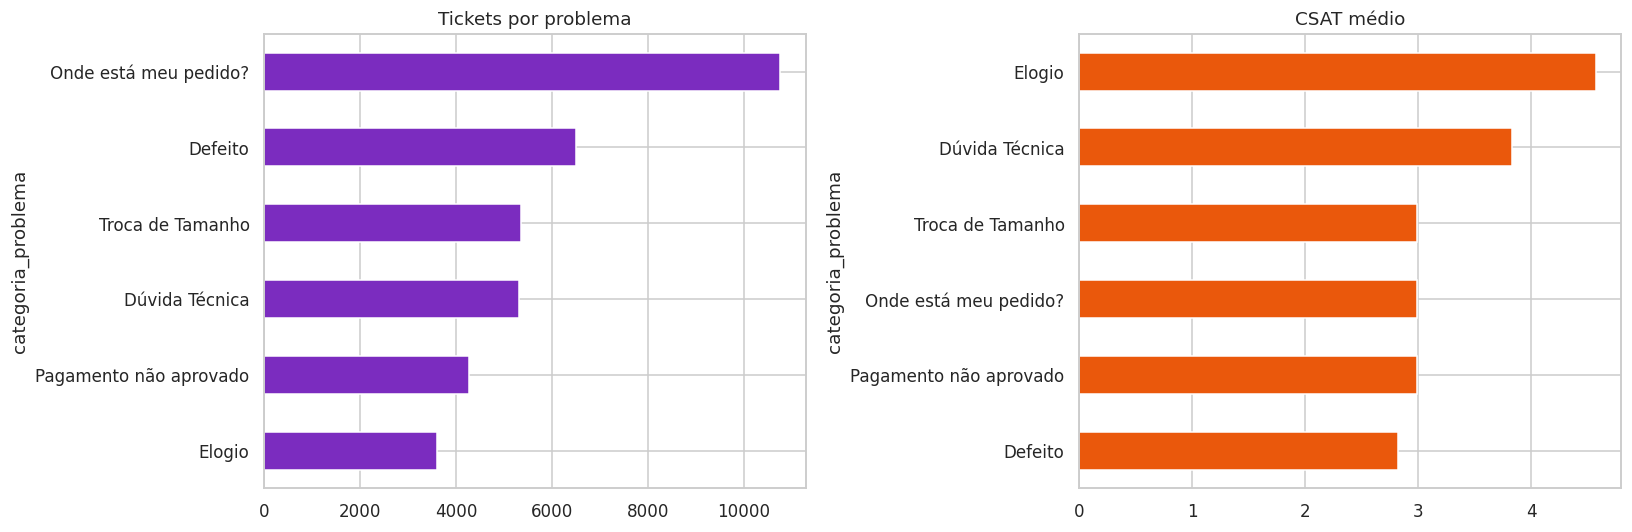

,tickets,custo,csat,primeira_resposta_min,resolvidos
categoria_problema,,,,,
Onde está meu pedido?,10765,159660.0,2.99,137.00,65.25
Defeito,6509,96592.0,2.82,135.87,64.07
Troca de Tamanho,5360,79325.0,2.99,131.22,66.19
Dúvida Técnica,5314,78888.0,3.83,136.50,65.32
Pagamento não aprovado,4281,63856.0,2.99,134.33,65.17
Elogio,3611,53939.0,4.57,135.73,65.05


Custo total: R$ 532,260.00
CSAT médio: 3.24 | primeira resposta média: 135 min


**Conclusão — atendimento:** Rastreamento, defeito e troca de tamanho concentram 63,2% dos tickets e formam um recorte operacional claro. Volume e custo são observados; economia continua dependente de contenção e parcela realmente evitável.

In [17]:
service_category = atendimento.groupby('categoria_problema').agg(
    tickets=('ticket_id', 'count'), custo=('custo_operacional_ticket', 'sum'),
    csat=('nota_csat', 'mean'), primeira_resposta_min=('tempo_primeira_resposta_minutos', 'mean'),
    resolvidos=('status_atendimento', lambda x: 100 * (x == 'Resolvido').mean())
).sort_values('tickets', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
service_category.tickets.sort_values().plot(kind='barh', ax=axes[0], color=COLORS['purple'], title='Tickets por problema')
service_category.csat.sort_values().plot(kind='barh', ax=axes[1], color=COLORS['orange'], title='CSAT médio')
plt.tight_layout()
plt.show()
display(service_category.round(2))
print(f'Custo total: R$ {atendimento.custo_operacional_ticket.sum():,.2f}')
print(f'CSAT médio: {atendimento.nota_csat.mean():.2f} | primeira resposta média: {atendimento.tempo_primeira_resposta_minutos.mean():.0f} min')
conclusion('atendimento', 'Rastreamento, defeito e troca de tamanho concentram 63,2% dos tickets e formam um recorte operacional claro. Volume e custo são observados; economia continua dependente de contenção e parcela realmente evitável.')

In [18]:
ticket_concentration = atendimento.customer_id.value_counts()
linked_tickets = atendimento[atendimento.order_id.isin(vendas.order_id)].merge(
    vendas[['order_id', 'devolvido_num', 'tempo_entrega_real', 'margem_contribuicao']],
    on='order_id', how='inner'
)
wismo = atendimento[atendimento.categoria_problema == 'Onde está meu pedido?']
wismo_cost = wismo.custo_operacional_ticket.sum()
containment = pd.DataFrame([
    {'contenção_pct': rate * 100, 'parcela_custo_evitável_pct': 70, 'economia_cenário': wismo_cost * rate * 0.70}
    for rate in [0.2, 0.4, 0.6]
])

service_linkage = pd.DataFrame([
    {'métrica': 'Tickets ligados a vendas', 'valor': len(linked_tickets), 'percentual': 100 * atendimento.order_id.isin(vendas.order_id).mean()},
    {'métrica': 'Top 1 cliente em tickets', 'valor': ticket_concentration.head(1).sum(), 'percentual': 100 * ticket_concentration.head(1).sum() / len(atendimento)},
    {'métrica': 'Top 10 clientes em tickets', 'valor': ticket_concentration.head(10).sum(), 'percentual': 100 * ticket_concentration.head(10).sum() / len(atendimento)},
    {'métrica': 'Onde está meu pedido?', 'valor': len(wismo), 'percentual': 100 * len(wismo) / len(atendimento)}
])
display(service_linkage.round(2))
display(containment.round(2))
conclusion('automação operacional', 'Autoatendimento de rastreamento é um go condicional baseado em regra e integração. Os valores são cenários conservadores; a concentração e a baixa cobertura de pedidos impedem extrapolação automática.')

,métrica,valor,percentual
0,Tickets ligados a vendas,12404,34.61
1,Top 1 cliente em tickets,14355,40.05
2,Top 10 clientes em tickets,29581,82.54
3,Onde está meu pedido?,10765,30.04


,contenção_pct,parcela_custo_evitável_pct,economia_cenário
0,20.0,70,22352.4
1,40.0,70,44704.8
2,60.0,70,67057.2


**Conclusão — automação operacional:** Autoatendimento de rastreamento é um go condicional baseado em regra e integração. Os valores são cenários conservadores; a concentração e a baixa cobertura de pedidos impedem extrapolação automática.

In [19]:
text_category = pd.crosstab(atendimento.texto_cliente, atendimento.categoria_problema)
text_purity = text_category.max(axis=1) / text_category.sum(axis=1)
text_diagnostics = pd.DataFrame([
    {'métrica': 'Tickets', 'valor': len(atendimento)},
    {'métrica': 'Textos únicos', 'valor': atendimento.texto_cliente.nunique()},
    {'métrica': 'Categorias', 'valor': atendimento.categoria_problema.nunique()},
    {'métrica': 'Pureza média texto→categoria', 'valor': text_purity.mean()},
    {'métrica': 'Pureza mínima texto→categoria', 'valor': text_purity.min()}
])
display(text_diagnostics)
display(pd.DataFrame({'textos_únicos': atendimento.groupby('categoria_problema').texto_cliente.nunique()}))
conclusion('corpus de atendimento', 'Há exatamente cinco frases por categoria e cada frase aparece em uma única classe. Um split aleatório mede memorização; generalização deve ser testada segurando frases inteiras fora do treino.')

,métrica,valor
0,Tickets,35840.0
1,Textos únicos,30.0
2,Categorias,6.0
3,Pureza média texto→categoria,1.0
4,Pureza mínima texto→categoria,1.0


,textos_únicos
categoria_problema,
Defeito,5
Dúvida Técnica,5
Elogio,5
Onde está meu pedido?,5
Pagamento não aprovado,5
Troca de Tamanho,5


**Conclusão — corpus de atendimento:** Há exatamente cinco frases por categoria e cada frase aparece em uma única classe. Um split aleatório mede memorização; generalização deve ser testada segurando frases inteiras fora do treino.

## 6. Estoque

O snapshot será analisado como fotografia operacional, não como série histórica de demanda.

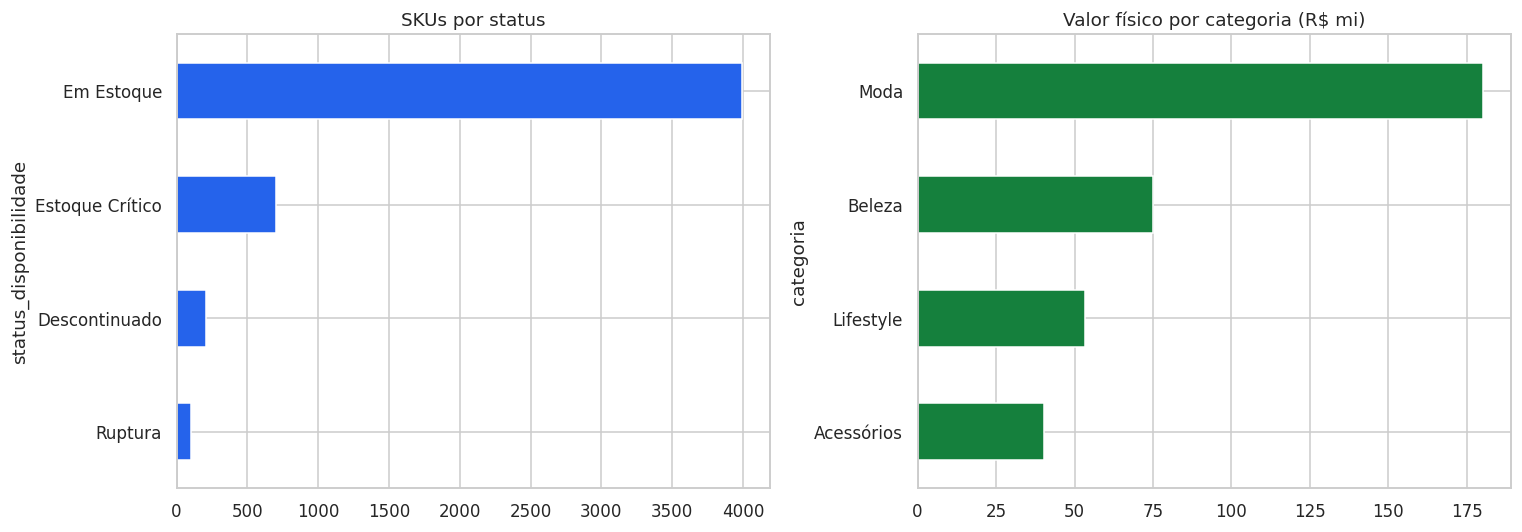

,skus,estoque_disponível,catálogo_pct
status_disponibilidade,,,
Descontinuado,207,65266,4.14
Em Estoque,3993,1319854,79.86
Estoque Crítico,701,34962,14.02
Ruptura,99,0,1.98


Abaixo do ponto de pedido: 787 SKUs
Valor físico: R$ 348,701,550.87


**Conclusão — status de estoque:** Ruptura real é 2,0%, não 20,1%. Estoque crítico e descontinuado devem permanecer separados porque pedem decisões diferentes.

In [20]:
stock_status = estoque.groupby('status_disponibilidade').agg(
    skus=('sku_id', 'count'), estoque_disponível=('estoque_disponivel', 'sum')
)
stock_status['catálogo_pct'] = 100 * stock_status.skus / len(estoque)
estoque['abaixo_ponto_pedido'] = estoque.estoque_disponivel < estoque.ponto_pedido
estoque['valor_físico'] = estoque.estoque_fisico * estoque.custo_unitario

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stock_status.skus.sort_values().plot(kind='barh', ax=axes[0], color=COLORS['blue'], title='SKUs por status')
estoque.groupby('categoria').valor_físico.sum().sort_values().div(1e6).plot(kind='barh', ax=axes[1], color=COLORS['green'], title='Valor físico por categoria (R$ mi)')
plt.tight_layout()
plt.show()
display(stock_status.round(2))
print(f'Abaixo do ponto de pedido: {estoque.abaixo_ponto_pedido.sum():,} SKUs')
print(f'Valor físico: R$ {estoque.valor_físico.sum():,.2f}')
assert stock_status.loc['Ruptura', 'skus'] == 99
assert stock_status.loc['Estoque Crítico', 'skus'] == 701
assert stock_status.loc['Descontinuado', 'skus'] == 207
conclusion('status de estoque', 'Ruptura real é 2,0%, não 20,1%. Estoque crítico e descontinuado devem permanecer separados porque pedem decisões diferentes.')

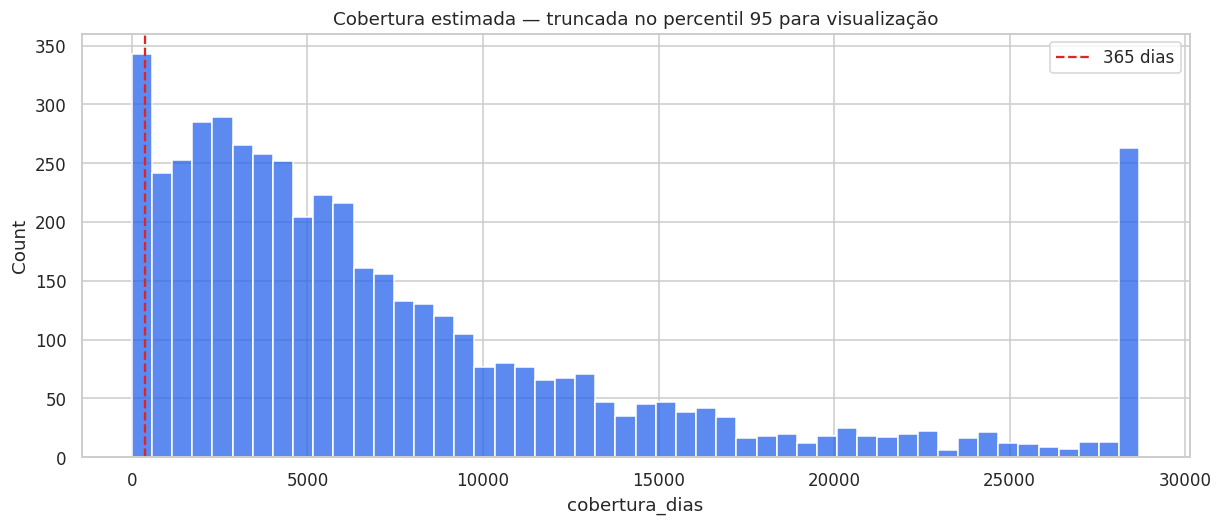

,métrica,valor
0,Meses observados de vendas,1.300000e+01
1,SKUs sem venda,8.200000e+01
2,Valor dos SKUs sem venda,6.682638e+06
3,Cobertura mediana finita (dias),5.304940e+03
4,SKUs vendidos com cobertura > 365d (%),9.516000e+01
5,Valor físico com cobertura > 365d,3.415958e+08


**Conclusão — cobertura:** A mediana estimada acima de 5 mil dias e 95,2% dos SKUs vendidos acima de um ano sinalizam incompatibilidade de escala ou dados sintéticos. Não representam recomendação imediata de liquidação.

In [21]:
months_observed = (vendas.data_pedido.max().to_period('M') - vendas.data_pedido.min().to_period('M')).n + 1
sku_demand = vendas.groupby('sku_id').quantidade.sum().rename('unidades_período').reset_index()
inventory_demand = estoque.merge(sku_demand, on='sku_id', how='left')
inventory_demand['unidades_período'] = inventory_demand.unidades_período.fillna(0)
inventory_demand['demanda_anualizada'] = inventory_demand.unidades_período / months_observed * 12
inventory_demand['cobertura_dias'] = np.where(
    inventory_demand.demanda_anualizada > 0,
    inventory_demand.estoque_disponivel / inventory_demand.demanda_anualizada * 365,
    np.inf
)
finite_cover = inventory_demand[np.isfinite(inventory_demand.cobertura_dias)]

fig, ax = plt.subplots(figsize=(13, 5))
sns.histplot(finite_cover.cobertura_dias.clip(upper=finite_cover.cobertura_dias.quantile(0.95)), bins=50, ax=ax, color=COLORS['blue'])
ax.axvline(365, color=COLORS['red'], linestyle='--', label='365 dias')
ax.set_title('Cobertura estimada — truncada no percentil 95 para visualização')
ax.legend()
plt.show()

stock_coverage = pd.DataFrame([
    {'métrica': 'Meses observados de vendas', 'valor': months_observed},
    {'métrica': 'SKUs sem venda', 'valor': int((inventory_demand.unidades_período == 0).sum())},
    {'métrica': 'Valor dos SKUs sem venda', 'valor': inventory_demand.loc[inventory_demand.unidades_período == 0, 'valor_físico'].sum()},
    {'métrica': 'Cobertura mediana finita (dias)', 'valor': finite_cover.cobertura_dias.median()},
    {'métrica': 'SKUs vendidos com cobertura > 365d (%)', 'valor': 100 * (finite_cover.cobertura_dias > 365).mean()},
    {'métrica': 'Valor físico com cobertura > 365d', 'valor': finite_cover.loc[finite_cover.cobertura_dias > 365, 'valor_físico'].sum()}
])
display(stock_coverage.round(2))
conclusion('cobertura', 'A mediana estimada acima de 5 mil dias e 95,2% dos SKUs vendidos acima de um ano sinalizam incompatibilidade de escala ou dados sintéticos. Não representam recomendação imediata de liquidação.')

In [22]:
def coverage_without_top_customers(n):
    excluded = customer_orders.head(n).index if n else []
    sample = vendas[~vendas.customer_id.isin(excluded)]
    demand = sample.groupby('sku_id').quantidade.sum()
    temp = estoque[['sku_id', 'estoque_disponivel']].copy()
    temp['units'] = temp.sku_id.map(demand).fillna(0)
    annual = temp.units / months_observed * 12
    days = np.where(annual > 0, temp.estoque_disponivel / annual * 365, np.inf)
    finite = days[np.isfinite(days)]
    return {'remoção': f'Top {n}' if n else 'Nenhuma', 'skus_com_demanda': len(finite), 'cobertura_mediana_dias': np.median(finite), 'pct_acima_365': 100 * np.mean(finite > 365)}

stock_sensitivity = pd.DataFrame([coverage_without_top_customers(n) for n in [0, 1, 5, 10]])
display(stock_sensitivity.round(2))
conclusion('sensibilidade de estoque', 'A cobertura piora quando os maiores clientes são removidos. Monitoramento de status é viável; previsão de demanda é no-go até haver vendas representativas, granularidade temporal e snapshots históricos.')

,remoção,skus_com_demanda,cobertura_mediana_dias,pct_acima_365
0,Nenhuma,4918,5304.94,95.16
1,Top 1,4678,8571.91,96.17
2,Top 5,3702,16607.50,97.14
3,Top 10,2965,20166.25,97.30


**Conclusão — sensibilidade de estoque:** A cobertura piora quando os maiores clientes são removidos. Monitoramento de status é viável; previsão de demanda é no-go até haver vendas representativas, granularidade temporal e snapshots históricos.

## 7. Cruzamentos e robustez

Nesta seção, os resultados são submetidos a remoção de outliers, alinhamento temporal e classificação do tipo de evidência.

In [23]:
common_start = max(vendas.data_pedido.min().normalize(), marketing.data_inicio.min(), atendimento.data_abertura.min().normalize())
common_end = min(vendas.data_pedido.max().normalize(), marketing.data_fim.max(), atendimento.data_abertura.max().normalize())
common_window = pd.DataFrame([
    {'base': 'Vendas', 'linhas_totais': len(vendas), 'linhas_janela_comum': vendas.data_pedido.between(common_start, common_end + pd.Timedelta(days=1)).sum()},
    {'base': 'Marketing', 'linhas_totais': len(marketing), 'linhas_janela_comum': marketing.data_inicio.between(common_start, common_end).sum()},
    {'base': 'Atendimento', 'linhas_totais': len(atendimento), 'linhas_janela_comum': atendimento.data_abertura.between(common_start, common_end + pd.Timedelta(days=1)).sum()}
])
common_window['cobertura_janela_pct'] = 100 * common_window.linhas_janela_comum / common_window.linhas_totais
print(f'Janela temporal comum aproximada: {common_start.date()} a {common_end.date()}')
display(common_window.round(2))
display(coverage.round(2))
conclusion('janela comum', 'Recortar datas melhora comparabilidade temporal, mas não cria atribuição. Datas de cadastro e última entrada de estoque não representam o mesmo tipo de evento que uma venda ou campanha.')

Janela temporal comum aproximada: 2023-01-01 a 2024-01-26


,base,linhas_totais,linhas_janela_comum,cobertura_janela_pct
0,Vendas,27758,27758,100.00
1,Marketing,3500,1224,34.97
2,Atendimento,35840,12589,35.13


,relação,cobertura_linhas_pct,chaves_origem,chaves_com_match
0,vendas.customer_id → clientes,100.00,346,346
1,atendimento.customer_id → clientes,100.00,445,445
2,atendimento.order_id → vendas,34.61,28589,9865
3,vendas.sku_id → estoque,100.00,4918,4918


**Conclusão — janela comum:** Recortar datas melhora comparabilidade temporal, mas não cria atribuição. Datas de cadastro e última entrada de estoque não representam o mesmo tipo de evento que uma venda ou campanha.

In [24]:
robust_metrics = []
for n in [0, 1, 5, 10]:
    excluded = customer_orders.head(n).index if n else []
    sample = vendas[~vendas.customer_id.isin(excluded)]
    marketplace_sample = sample[sample.canal == 'Marketplace']
    robust_metrics.append({
        'remoção': f'Top {n}' if n else 'Nenhuma',
        'receita_pct_retida': 100 * sample.receita_bruta.sum() / vendas.receita_bruta.sum(),
        'margem_geral_pct': 100 * sample.margem_contribuicao.sum() / sample.receita_bruta.sum(),
        'margem_marketplace_pct': 100 * marketplace_sample.margem_contribuicao.sum() / marketplace_sample.receita_bruta.sum(),
        'devolução_pct': 100 * sample.devolvido_num.mean(),
        'frete_marketplace_pct': 100 * marketplace_sample.custo_frete.sum() / marketplace_sample.receita_bruta.sum()
    })
robust_metrics = pd.DataFrame(robust_metrics)
display(robust_metrics.round(2))

stability = robust_metrics.set_index('remoção')[['margem_geral_pct', 'margem_marketplace_pct', 'devolução_pct', 'frete_marketplace_pct']].max() - robust_metrics.set_index('remoção')[['margem_geral_pct', 'margem_marketplace_pct', 'devolução_pct', 'frete_marketplace_pct']].min()
display(stability.rename('amplitude').to_frame().round(3))
conclusion('robustez', 'As taxas agregadas são estáveis mesmo quando a maior parte do volume é removida. Isso sugere dados gerados com proporções repetidas: serve para testar cálculos, mas não para validar comportamento real de clientes.')

,remoção,receita_pct_retida,margem_geral_pct,margem_marketplace_pct,devolução_pct,frete_marketplace_pct
0,Nenhuma,100.00,50.04,47.45,14.87,4.55
1,Top 1,59.30,50.00,47.43,14.80,4.61
2,Top 5,25.84,49.91,47.66,14.38,4.68
3,Top 10,16.95,49.88,47.78,14.76,4.54


,amplitude
margem_geral_pct,0.158
margem_marketplace_pct,0.350
devolução_pct,0.483
frete_marketplace_pct,0.135


**Conclusão — robustez:** As taxas agregadas são estáveis mesmo quando a maior parte do volume é removida. Isso sugere dados gerados com proporções repetidas: serve para testar cálculos, mas não para validar comportamento real de clientes.

In [25]:
# Relações categóricas com devolução e relação entre entrega e devolução.
association_rows = []
for dimension in ['canal', 'categoria']:
    table = pd.crosstab(vendas[dimension], vendas.devolvido_num)
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / (table.to_numpy().sum() * (min(table.shape) - 1)))
    rate_range = 100 * vendas.groupby(dimension).devolvido_num.mean().pipe(lambda x: x.max() - x.min())
    association_rows.append({'teste': f'Devolução por {dimension}', 'p': p_value, 'tamanho_efeito': cramers_v, 'amplitude_pp': rate_range, 'tipo': 'associação observacional'})

delivered = vendas[vendas.devolvido_num == 1].tempo_entrega_real
not_delivered = vendas[vendas.devolvido_num == 0].tempo_entrega_real
delivery_test = stats.ttest_ind(delivered, not_delivered, equal_var=False)
pooled_sd = np.sqrt((delivered.var() + not_delivered.var()) / 2)
association_rows.append({'teste': 'Tempo de entrega por devolução', 'p': delivery_test.pvalue, 'tamanho_efeito': (delivered.mean() - not_delivered.mean()) / pooled_sd, 'amplitude_pp': np.nan, 'tipo': 'associação observacional'})

associations = pd.DataFrame(association_rows)
display(associations.round(4))

evidence_maturity = pd.DataFrame([
    {'achado': 'Desconto e margem', 'natureza': 'Relação parcialmente mecânica', 'pode_causar_decisão': 'Sim, como cenário de política promocional'},
    {'achado': 'Frete do Marketplace', 'natureza': 'Decomposição financeira observada', 'pode_causar_decisão': 'Sim, após validar regra logística'},
    {'achado': 'Categoria/canal e devolução', 'natureza': 'Sem associação relevante', 'pode_causar_decisão': 'Não segmentar modelo por essas variáveis'},
    {'achado': 'Entrega e devolução', 'natureza': 'Correlação não suportada', 'pode_causar_decisão': 'Investigar processo, não afirmar causalidade'},
    {'achado': 'Marketing e LTV', 'natureza': 'Não atribuível', 'pode_causar_decisão': 'Bloquear otimização cross-base'}
])
display(evidence_maturity)
conclusion('causalidade', 'Canal, categoria e tempo de entrega não explicam devolução com efeito relevante nesta amostra. A solução deve mostrar limitações e rejeitar recomendações causais sem evidência.')

,teste,p,tamanho_efeito,amplitude_pp,tipo
0,Devolução por canal,0.9045,0.0088,0.8992,associação observacional
1,Devolução por categoria,0.1827,0.0132,1.1834,associação observacional
2,Tempo de entrega por devolução,0.1499,0.0242,NaN,associação observacional


,achado,natureza,pode_causar_decisão
0,Desconto e margem,Relação parcialmente mecânica,"Sim, como cenário de política promocional"
1,Frete do Marketplace,Decomposição financeira observada,"Sim, após validar regra logística"
2,Categoria/canal e devolução,Sem associação relevante,Não segmentar modelo por essas variáveis
3,Entrega e devolução,Correlação não suportada,"Investigar processo, não afirmar causalidade"
4,Marketing e LTV,Não atribuível,Bloquear otimização cross-base


**Conclusão — causalidade:** Canal, categoria e tempo de entrega não explicam devolução com efeito relevante nesta amostra. A solução deve mostrar limitações e rejeitar recomendações causais sem evidência.

## 8. Viabilidade de ML e IA

Critério de `go` para risco de devolução: avaliação temporal com ROC-AUC ≥ 0,60 usando somente informações disponíveis antes do desfecho.

In [26]:
return_features = [
    'canal', 'categoria', 'quantidade', 'preco_unitario', 'receita_bruta',
    'desconto_reais', 'custo_frete', 'metodo_pagamento'
]
categorical_features = ['canal', 'categoria', 'metodo_pagamento']
numeric_features = [col for col in return_features if col not in categorical_features]

preprocessing = ColumnTransformer([
    ('categorical', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), categorical_features),
    ('numeric', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numeric_features)
])
return_model = make_pipeline(
    preprocessing,
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
)

temporal_cut = pd.Timestamp('2023-11-01')
train_mask = vendas.data_pedido < temporal_cut
X_return = vendas[return_features]
y_return = vendas.devolvido_num
return_model.fit(X_return[train_mask], y_return[train_mask])
return_probability = return_model.predict_proba(X_return[~train_mask])[:, 1]
return_auc = roc_auc_score(y_return[~train_mask], return_probability)

return_ml_result = pd.DataFrame([{
    'modelo': 'Regressão logística — risco de devolução',
    'treino_até': str((temporal_cut - pd.Timedelta(days=1)).date()),
    'linhas_teste': int((~train_mask).sum()),
    'prevalência_teste': y_return[~train_mask].mean(),
    'roc_auc': return_auc,
    'limiar_go': 0.60,
    'decisão': 'GO' if return_auc >= 0.60 else 'NO-GO'
}])
display(return_ml_result.round(4))
conclusion('ML de devolução', f'O ROC-AUC temporal de {return_auc:.3f} é equivalente ao acaso e abaixo do gate de 0,60. O módulo preditivo é no-go; faltam sinais anteriores ao pedido, produto, fornecedor, tamanho, histórico e logística.')

,modelo,treino_até,linhas_teste,prevalência_teste,roc_auc,limiar_go,decisão
0,Regressão logística — risco de devolução,2023-10-31,8620,0.1462,0.497,0.6,NO-GO


**Conclusão — ML de devolução:** O ROC-AUC temporal de 0.497 é equivalente ao acaso e abaixo do gate de 0,60. O módulo preditivo é no-go; faltam sinais anteriores ao pedido, produto, fornecedor, tamanho, histórico e logística.

In [27]:
# Baseline ingênuo: frases repetidas são divididas aleatoriamente entre treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    atendimento.texto_cliente, atendimento.categoria_problema,
    test_size=0.25, random_state=RANDOM_STATE, stratify=atendimento.categoria_problema
)
random_text_model = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
random_text_model.fit(X_train, y_train)
random_prediction = random_text_model.predict(X_test)

# Teste honesto: uma frase inteira de cada categoria nunca aparece no treino.
unique_pairs = atendimento[['texto_cliente', 'categoria_problema']].drop_duplicates().sort_values(['categoria_problema', 'texto_cliente'])
held_out_texts = set(unique_pairs.groupby('categoria_problema').tail(1).texto_cliente)
unseen_mask = atendimento.texto_cliente.isin(held_out_texts)
unseen_text_model = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
unseen_text_model.fit(atendimento.loc[~unseen_mask, 'texto_cliente'], atendimento.loc[~unseen_mask, 'categoria_problema'])
unseen_prediction = unseen_text_model.predict(atendimento.loc[unseen_mask, 'texto_cliente'])

ticket_ml_result = pd.DataFrame([
    {'avaliação': 'Split aleatório por linha', 'accuracy': accuracy_score(y_test, random_prediction), 'macro_f1': f1_score(y_test, random_prediction, average='macro'), 'risco': 'Memorização de frases repetidas'},
    {'avaliação': 'Frases inteiras não vistas', 'accuracy': accuracy_score(atendimento.loc[unseen_mask, 'categoria_problema'], unseen_prediction), 'macro_f1': f1_score(atendimento.loc[unseen_mask, 'categoria_problema'], unseen_prediction, average='macro'), 'risco': 'Teste mínimo de generalização'}
])
display(ticket_ml_result.round(4))
conclusion('ML de tickets', 'A acurácia cai de 100% para cerca de 27% quando frases novas são mantidas fora do treino. O classificador é no-go; o MVP deve usar as categorias existentes e regras até obter textos reais e diversos.')

,avaliação,accuracy,macro_f1,risco
0,Split aleatório por linha,1.0000,1.0000,Memorização de frases repetidas
1,Frases inteiras não vistas,0.2678,0.2374,Teste mínimo de generalização


**Conclusão — ML de tickets:** A acurácia cai de 100% para cerca de 27% quando frases novas são mantidas fora do treino. O classificador é no-go; o MVP deve usar as categorias existentes e regras até obter textos reais e diversos.

In [28]:
ml_gates = pd.DataFrame([
    {'módulo': 'Risco de devolução', 'evidência': f'ROC-AUC temporal {return_auc:.3f}', 'decisão': 'NO-GO', 'condição_para_reavaliar': 'Features pré-pedido, fornecedor, tamanho, histórico e logística'},
    {'módulo': 'Classificação de tickets', 'evidência': f'{atendimento.texto_cliente.nunique()} textos; F1 não visto {f1_score(atendimento.loc[unseen_mask, "categoria_problema"], unseen_prediction, average="macro"):.3f}', 'decisão': 'NO-GO', 'condição_para_reavaliar': 'Corpus real, diverso, deduplicado e avaliação por grupos'},
    {'módulo': 'Otimizador de marketing', 'evidência': 'Sem campanha→pedido→cliente', 'decisão': 'NO-GO', 'condição_para_reavaliar': 'Atribuição e janela financeira reconciliada'},
    {'módulo': 'Previsão de demanda', 'evidência': f'{months_observed} meses e cobertura incompatível', 'decisão': 'NO-GO', 'condição_para_reavaliar': '24+ meses, demanda representativa e snapshots históricos'},
    {'módulo': 'Narrativa generativa', 'evidência': 'Evidências agregadas e cálculos determinísticos disponíveis', 'decisão': 'GO CONDICIONAL', 'condição_para_reavaliar': 'Schema estruturado, evidence_ids, crítico e fallback'}
])
display(ml_gates)
conclusion('papel da IA', 'IA generativa pode sintetizar e criticar evidências estruturadas. Ela não deve calcular métricas, substituir as validações ou esconder um no-go de ML.')

,módulo,evidência,decisão,condição_para_reavaliar
0,Risco de devolução,ROC-AUC temporal 0.497,NO-GO,"Features pré-pedido, fornecedor, tamanho, histórico e logística"
1,Classificação de tickets,30 textos; F1 não visto 0.237,NO-GO,"Corpus real, diverso, deduplicado e avaliação por grupos"
2,Otimizador de marketing,Sem campanha→pedido→cliente,NO-GO,Atribuição e janela financeira reconciliada
3,Previsão de demanda,13 meses e cobertura incompatível,NO-GO,"24+ meses, demanda representativa e snapshots históricos"
4,Narrativa generativa,Evidências agregadas e cálculos determinísticos disponíveis,GO CONDICIONAL,"Schema estruturado, evidence_ids, crítico e fallback"


**Conclusão — papel da IA:** IA generativa pode sintetizar e criticar evidências estruturadas. Ela não deve calcular métricas, substituir as validações ou esconder um no-go de ML.

## 9. Síntese: hipóteses testadas

Os status abaixo constituem a decisão final desta EDA. `Suportada` não significa causalidade; significa que a evidência observada é suficiente para a decisão explicitada.

In [29]:
hypotheses = pd.DataFrame([
    {'id': 'H1', 'pergunta': 'A margem está em deterioração estrutural?', 'teste': 'Regressão mensal', 'evidência': f'Slope {trend.slope:.3f} p.p./mês; p={trend.pvalue:.3f}', 'tamanho_do_efeito': f'IC95% [{slope_ci[0]:.3f}; {slope_ci[1]:.3f}]', 'status': 'Inconclusiva', 'limitação': '13 meses; janeiro parcial', 'decisão_de_negócio': 'Não vender narrativa de queda estrutural'},
    {'id': 'H2', 'pergunta': 'Marketplace possui vazamento de frete?', 'teste': 'Decomposição por canal', 'evidência': f'Margem {marketplace.margem_pct:.2f}%; frete {marketplace.frete_pct:.2f}%', 'tamanho_do_efeito': f'Cenário R$ {opportunity_marketplace:,.0f}', 'status': 'Suportada', 'limitação': 'Regra logística não disponível', 'decisão_de_negócio': 'Priorizar simulador de frete'},
    {'id': 'H3', 'pergunta': 'Canal ou categoria explicam devoluções?', 'teste': 'Qui-quadrado e Cramér V', 'evidência': f'p canal={associations.iloc[0].p:.3f}; p categoria={associations.iloc[1].p:.3f}', 'tamanho_do_efeito': 'V < 0,014', 'status': 'Refutada', 'limitação': 'Variáveis pré-pedido limitadas', 'decisão_de_negócio': 'Não segmentar regra preditiva atual'},
    {'id': 'H4', 'pergunta': 'Qual é a margem realizada após devoluções?', 'teste': 'Cenários de recuperação', 'evidência': f'{len(returned):,} devoluções; R$ {returned.receita_bruta.sum():,.0f} brutos associados', 'tamanho_do_efeito': 'Margem cenário 36,31%–42,37%', 'status': 'Não verificável', 'limitação': 'Sem reembolso, recuperação e logística reversa', 'decisão_de_negócio': 'Construir simulador, não KPI realizado'},
    {'id': 'H5', 'pergunta': 'Marketing pode ser otimizado por margem/LTV?', 'teste': 'Cobertura temporal e chaves', 'evidência': f'R$ {overlap.investimento_reais.sum()/1e6:.1f} mi investidos vs. R$ {vendas.receita_bruta.sum()/1e6:.1f} mi em vendas', 'tamanho_do_efeito': 'Sem universo reconciliável', 'status': 'Não verificável', 'limitação': 'Sem atribuição campanha→pedido→cliente', 'decisão_de_negócio': 'Liberar monitor; bloquear otimizador'},
    {'id': 'H6', 'pergunta': 'Segmentos permitem decisões de retenção/churn?', 'teste': 'Cobertura e reconciliação', 'evidência': f'{len(linked_customers)} clientes ligados ({100*len(linked_customers)/len(clientes):.1f}%)', 'tamanho_do_efeito': 'Top 10 = 83,2% dos pedidos', 'status': 'Não verificável', 'limitação': 'Histórico e LTV incompatíveis', 'decisão_de_negócio': 'Não priorizar motor de retenção'},
    {'id': 'H7', 'pergunta': 'Atendimento concentra demandas repetitivas?', 'teste': 'Volume, custo e CSAT', 'evidência': f'WISMO {len(wismo):,} tickets; top 3 = {100*service_category.head(3).tickets.sum()/len(atendimento):.1f}%', 'tamanho_do_efeito': f'Custo WISMO R$ {wismo_cost:,.0f}', 'status': 'Suportada', 'limitação': 'Economia depende de contenção', 'decisão_de_negócio': 'Go condicional para regras/autoatendimento'},
    {'id': 'H8', 'pergunta': 'Classificador de tickets generaliza?', 'teste': 'Frases inéditas fora do treino', 'evidência': f'30 textos; accuracy inédita {accuracy_score(atendimento.loc[unseen_mask, "categoria_problema"], unseen_prediction):.3f}', 'tamanho_do_efeito': 'Queda de 1,00 para ~0,27', 'status': 'No-go para ML', 'limitação': 'Corpus sintético e repetido', 'decisão_de_negócio': 'Usar categoria existente e regras'},
    {'id': 'H9', 'pergunta': '20,1% do catálogo está em ruptura?', 'teste': 'Separação de status', 'evidência': '99 rupturas; 701 críticos; 207 descontinuados', 'tamanho_do_efeito': 'Ruptura real 2,0%', 'status': 'Refutada', 'limitação': 'Snapshot único', 'decisão_de_negócio': 'Monitorar status separadamente'},
    {'id': 'H10', 'pergunta': 'Previsão de demanda é defensável?', 'teste': 'Cobertura, histórico e sensibilidade', 'evidência': f'Mediana {finite_cover.cobertura_dias.median():.0f} dias; {months_observed} meses', 'tamanho_do_efeito': f'{100*(finite_cover.cobertura_dias>365).mean():.1f}% acima de 365d', 'status': 'No-go para ML', 'limitação': 'Escala incompatível e sem snapshots', 'decisão_de_negócio': 'Monitor go; forecast bloqueado'},
    {'id': 'H11', 'pergunta': 'Risco de devolução é previsível agora?', 'teste': 'Regressão logística temporal', 'evidência': f'ROC-AUC {return_auc:.3f}', 'tamanho_do_efeito': 'Abaixo do gate 0,60', 'status': 'No-go para ML', 'limitação': 'Features sem sinal', 'decisão_de_negócio': 'Coletar dados antes de modelar'},
    {'id': 'H12', 'pergunta': 'Qualidade de dados deve integrar o produto?', 'teste': 'Schemas, cobertura e consistência', 'evidência': f'{len(issues)} achados materiais', 'tamanho_do_efeito': 'Bloqueia 4 módulos avançados', 'status': 'Suportada', 'limitação': 'Dados do case são uma fotografia', 'decisão_de_negócio': 'Qualidade é primeira etapa do MVP'}
])

allowed_statuses = {'Suportada', 'Refutada', 'Inconclusiva', 'Não verificável', 'No-go para ML'}
assert set(hypotheses.status).issubset(allowed_statuses)
assert hypotheses[['evidência', 'limitação', 'decisão_de_negócio']].notna().all().all()
display(hypotheses)

,id,pergunta,teste,evidência,tamanho_do_efeito,status,limitação,decisão_de_negócio
0,H1,A margem está em deterioração estrutural?,Regressão mensal,Slope -0.080 p.p./mês; p=0.136,IC95% [-0.189; 0.029],Inconclusiva,13 meses; janeiro parcial,Não vender narrativa de queda estrutural
1,H2,Marketplace possui vazamento de frete?,Decomposição por canal,Margem 47.45%; frete 4.55%,"Cenário R$ 111,615",Suportada,Regra logística não disponível,Priorizar simulador de frete
2,H3,Canal ou categoria explicam devoluções?,Qui-quadrado e Cramér V,p canal=0.905; p categoria=0.183,"V < 0,014",Refutada,Variáveis pré-pedido limitadas,Não segmentar regra preditiva atual
3,H4,Qual é a margem realizada após devoluções?,Cenários de recuperação,"4,127 devoluções; R$ 3,063,301 brutos associados","Margem cenário 36,31%–42,37%",Não verificável,"Sem reembolso, recuperação e logística reversa","Construir simulador, não KPI realizado"
4,H5,Marketing pode ser otimizado por margem/LTV?,Cobertura temporal e chaves,R$ 75.5 mi investidos vs. R$ 20.5 mi em vendas,Sem universo reconciliável,Não verificável,Sem atribuição campanha→pedido→cliente,Liberar monitor; bloquear otimizador
5,H6,Segmentos permitem decisões de retenção/churn?,Cobertura e reconciliação,346 clientes ligados (2.3%),"Top 10 = 83,2% dos pedidos",Não verificável,Histórico e LTV incompatíveis,Não priorizar motor de retenção
6,H7,Atendimento concentra demandas repetitivas?,"Volume, custo e CSAT","WISMO 10,765 tickets; top 3 = 63.2%","Custo WISMO R$ 159,660",Suportada,Economia depende de contenção,Go condicional para regras/autoatendimento
7,H8,Classificador de tickets generaliza?,Frases inéditas fora do treino,30 textos; accuracy inédita 0.268,"Queda de 1,00 para ~0,27",No-go para ML,Corpus sintético e repetido,Usar categoria existente e regras
8,H9,"20,1% do catálogo está em ruptura?",Separação de status,99 rupturas; 701 críticos; 207 descontinuados,"Ruptura real 2,0%",Refutada,Snapshot único,Monitorar status separadamente
9,H10,Previsão de demanda é defensável?,"Cobertura, histórico e sensibilidade",Mediana 5305 dias; 13 meses,95.2% acima de 365d,No-go para ML,Escala incompatível e sem snapshots,Monitor go; forecast bloqueado


## 10. Backlog do MVP orientado por evidências

Prioridade considera utilidade decisória, força da evidência e possibilidade de demonstração em 90 dias. Itens bloqueados permanecem visíveis para evitar que limitações sejam esquecidas.

In [30]:
backlog = pd.DataFrame([
    {'funcionalidade': 'Gate de qualidade dos cinco CSVs', 'problema': 'Bases incompatíveis podem produzir recomendações falsas', 'evidência': 'Cobertura, períodos e reconciliações desta EDA', 'decisão suportada': 'Executar, limitar ou bloquear análise', 'papel da IA': 'Explicar; validação determinística', 'confiança': 'Alta', 'prioridade': 'P0 — GO', 'dados faltantes': 'Contrato de produção e tolerâncias acordadas'},
    {'funcionalidade': 'Diagnóstico determinístico de margem', 'problema': 'Vazamentos ficam diluídos no agregado', 'evidência': 'Waterfall, canal, categoria e sensibilidade', 'decisão suportada': 'Localizar vazamento e sua base contábil', 'papel da IA': 'Síntese com evidence_ids', 'confiança': 'Alta', 'prioridade': 'P0 — GO', 'dados faltantes': 'Comissões e tributos, se aplicáveis'},
    {'funcionalidade': 'Simulador de frete do Marketplace', 'problema': 'Frete de 4,55% reduz margem do canal', 'evidência': f'Cenário teórico R$ {opportunity_marketplace:,.0f}', 'decisão suportada': 'Testar pedido mínimo, subsídio e fulfillment', 'papel da IA': 'Explicar alternativas', 'confiança': 'Alta', 'prioridade': 'P1 — GO', 'dados faltantes': 'Tabela logística, CEP, peso e SLA'},
    {'funcionalidade': 'Simulador de devoluções', 'problema': 'Margem registrada não reflete o pós-devolução', 'evidência': 'Cenários de recuperação 0/50/100%', 'decisão suportada': 'Comparar políticas e causas-raiz', 'papel da IA': 'Criticar premissas', 'confiança': 'Média', 'prioridade': 'P1 — GO condicional', 'dados faltantes': 'Reembolso, recuperação, logística reversa e processamento'},
    {'funcionalidade': 'Autoatendimento de rastreamento por regras', 'problema': 'WISMO concentra 30% dos tickets', 'evidência': f'{len(wismo):,} tickets; custo R$ {wismo_cost:,.0f}', 'decisão suportada': 'Priorizar comunicação proativa e tracking', 'papel da IA': 'Redigir resposta; regra decide status', 'confiança': 'Média', 'prioridade': 'P1 — GO condicional', 'dados faltantes': 'Eventos reais de tracking e taxa de contenção'},
    {'funcionalidade': 'Narrativa executiva auditável', 'problema': 'Resultados técnicos não viram decisão', 'evidência': 'Métricas e limitações estruturadas', 'decisão suportada': 'Gerar top 3 ações e memo', 'papel da IA': 'Síntese e crítica, sem calcular', 'confiança': 'Alta', 'prioridade': 'P1 — GO condicional', 'dados faltantes': 'Avaliação de factualidade e fallback'},
    {'funcionalidade': 'Monitor de campanhas', 'problema': 'Média por canal esconde dispersão', 'evidência': f'{len(low_roas)} campanhas com ROAS < 1', 'decisão suportada': 'Alertar campanhas internamente ineficientes', 'papel da IA': 'Explicar anomalia', 'confiança': 'Média', 'prioridade': 'P2 — GO limitado', 'dados faltantes': 'Metas e contexto de campanha'},
    {'funcionalidade': 'Preditor de devolução', 'problema': 'Desejo de prevenção por pedido', 'evidência': f'ROC-AUC temporal {return_auc:.3f}', 'decisão suportada': 'Nenhuma decisão confiável agora', 'papel da IA': 'Não aplicável', 'confiança': 'Alta no no-go', 'prioridade': 'BLOQUEADO', 'dados faltantes': 'Features pré-pedido e histórico real'},
    {'funcionalidade': 'Classificador ML de tickets', 'problema': 'Triagem manual', 'evidência': '30 frases; generalização ruim', 'decisão suportada': 'Usar categorias/regras existentes', 'papel da IA': 'Não treinar com este corpus', 'confiança': 'Alta no no-go', 'prioridade': 'BLOQUEADO', 'dados faltantes': 'Textos reais e diversos'},
    {'funcionalidade': 'Otimizador de orçamento', 'problema': 'Alocação por volume, não margem', 'evidência': 'Sem atribuição e universos incompatíveis', 'decisão suportada': 'Não realocar cross-base', 'papel da IA': 'Não aplicável', 'confiança': 'Alta no no-go', 'prioridade': 'BLOQUEADO', 'dados faltantes': 'campanha_id no pedido e coortes'},
    {'funcionalidade': 'Previsão de demanda', 'problema': 'Ruptura e excesso', 'evidência': '13 meses, snapshot único e concentração', 'decisão suportada': 'Monitorar, não prever', 'papel da IA': 'Não aplicável', 'confiança': 'Alta no no-go', 'prioridade': 'BLOQUEADO', 'dados faltantes': '24+ meses e snapshots históricos'}
])
assert backlog[['evidência', 'decisão suportada', 'dados faltantes']].notna().all().all()
display(backlog)

,funcionalidade,problema,evidência,decisão suportada,papel da IA,confiança,prioridade,dados faltantes
0,Gate de qualidade dos cinco CSVs,Bases incompatíveis podem produzir recomendações falsas,"Cobertura, períodos e reconciliações desta EDA","Executar, limitar ou bloquear análise",Explicar; validação determinística,Alta,P0 — GO,Contrato de produção e tolerâncias acordadas
1,Diagnóstico determinístico de margem,Vazamentos ficam diluídos no agregado,"Waterfall, canal, categoria e sensibilidade",Localizar vazamento e sua base contábil,Síntese com evidence_ids,Alta,P0 — GO,"Comissões e tributos, se aplicáveis"
2,Simulador de frete do Marketplace,"Frete de 4,55% reduz margem do canal","Cenário teórico R$ 111,615","Testar pedido mínimo, subsídio e fulfillment",Explicar alternativas,Alta,P1 — GO,"Tabela logística, CEP, peso e SLA"
3,Simulador de devoluções,Margem registrada não reflete o pós-devolução,Cenários de recuperação 0/50/100%,Comparar políticas e causas-raiz,Criticar premissas,Média,P1 — GO condicional,"Reembolso, recuperação, logística reversa e processamento"
4,Autoatendimento de rastreamento por regras,WISMO concentra 30% dos tickets,"10,765 tickets; custo R$ 159,660",Priorizar comunicação proativa e tracking,Redigir resposta; regra decide status,Média,P1 — GO condicional,Eventos reais de tracking e taxa de contenção
5,Narrativa executiva auditável,Resultados técnicos não viram decisão,Métricas e limitações estruturadas,Gerar top 3 ações e memo,"Síntese e crítica, sem calcular",Alta,P1 — GO condicional,Avaliação de factualidade e fallback
6,Monitor de campanhas,Média por canal esconde dispersão,12 campanhas com ROAS < 1,Alertar campanhas internamente ineficientes,Explicar anomalia,Média,P2 — GO limitado,Metas e contexto de campanha
7,Preditor de devolução,Desejo de prevenção por pedido,ROC-AUC temporal 0.497,Nenhuma decisão confiável agora,Não aplicável,Alta no no-go,BLOQUEADO,Features pré-pedido e histórico real
8,Classificador ML de tickets,Triagem manual,30 frases; generalização ruim,Usar categorias/regras existentes,Não treinar com este corpus,Alta no no-go,BLOQUEADO,Textos reais e diversos
9,Otimizador de orçamento,"Alocação por volume, não margem",Sem atribuição e universos incompatíveis,Não realocar cross-base,Não aplicável,Alta no no-go,BLOQUEADO,campanha_id no pedido e coortes


In [31]:
# Critérios de aceite numéricos do notebook.
assert round(margem_geral, 2) == 50.04
assert round(marketplace.margem_pct, 2) == 47.45
assert round(marketplace.frete_pct, 2) == 4.55
assert round(100 * vendas.devolvido_num.mean(), 2) == 14.87
assert len(wismo) == 10765
assert int((estoque.status_disponibilidade == 'Ruptura').sum()) == 99
assert return_auc < 0.60
assert atendimento.texto_cliente.nunique() == 30

print('=' * 76)
print('SÍNTESE EXECUTIVA — EDA V2 CONCLUÍDA')
print('=' * 76)
print('1. Não há evidência suficiente de deterioração estrutural da margem.')
print('2. Frete do Marketplace é o vazamento financeiro mais claro e acionável.')
print('3. Devoluções e WISMO justificam simuladores e automação por regras, não ML atual.')
print('4. Marketing, clientes e estoque possuem incompatibilidades que bloqueiam decisões avançadas.')
print('5. Os baselines de ML reprovaram generalização; o resultado negativo orienta coleta de dados.')
print('6. O MVP deve começar por qualidade → diagnóstico determinístico → cenário → narrativa auditável.')
print()
print(f'Hipóteses registradas: {len(hypotheses)} | itens de backlog: {len(backlog)}')
print('Todos os critérios de aceite numéricos passaram.')

SÍNTESE EXECUTIVA — EDA V2 CONCLUÍDA
1. Não há evidência suficiente de deterioração estrutural da margem.
2. Frete do Marketplace é o vazamento financeiro mais claro e acionável.
3. Devoluções e WISMO justificam simuladores e automação por regras, não ML atual.
4. Marketing, clientes e estoque possuem incompatibilidades que bloqueiam decisões avançadas.
5. Os baselines de ML reprovaram generalização; o resultado negativo orienta coleta de dados.
6. O MVP deve começar por qualidade → diagnóstico determinístico → cenário → narrativa auditável.

Hipóteses registradas: 12 | itens de backlog: 11
Todos os critérios de aceite numéricos passaram.
